# Inférence statistique

## Auto-ML

pycaret ne supporte pas encore officiellement Python 3.14.3 donc on utilise à la place le package flaml

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_predict
from flaml import AutoML

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

In [4]:
colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

# Séparation des features et de la variable cible
joueurs_test = df_test[colonne_joueur]

# On supprime les colonnes texte et la cible pour l'entraînement
cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position", "market_value_in_eur_nor"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

In [5]:
print("--- Entraînement FLAML ---")
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task="regression",
    metric="mae",
    time_budget=300,  # 5 minutes pour FLAML
    estimator_list=["xgboost", "lgbm", "catboost", "rf", "extra_tree", "kneighbor", "enet", "lassolars"],
    seed=1308
)

# Récupération des meilleures prédictions de FLAML
preds_flaml = automl.predict(X_test)
mae_flaml   = mean_absolute_error(y_test, preds_flaml)


# Préparation : Sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f" -> {len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]} (0 NaN).")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]


print("\n--- Entraînement SVR ---")
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_svr = {
    'svr__C':       [0.1, 1, 10, 100],
    'svr__kernel':  ['rbf', 'linear'],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

grid_svr = GridSearchCV(svr_pipeline, param_svr, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_svr.fit(X_train_sans_nan, y_train)

preds_svr = grid_svr.predict(X_test_sans_nan)
mae_svr   = mean_absolute_error(y_test, preds_svr)


print("--- Entraînement Régression Linéaire ---")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train_sans_nan, y_train)

preds_lr = lr_pipeline.predict(X_test_sans_nan)
mae_lr   = mean_absolute_error(y_test, preds_lr)


print("\nComparaison des performances (MAE)")
print(f"FLAML                                : {mae_flaml:,.0f} € (Modèle : {automl.best_estimator})")
print(f"SVR (Optimisé par GridSearch)        : {mae_svr:,.0f} €")
print(f"Régression Linéaire Multiple         : {mae_lr:,.0f} €")

resultats_automl = {
    "FLAML":            (mae_flaml, preds_flaml),
    "SVR":              (mae_svr,   preds_svr),
    "LinearRegression": (mae_lr,    preds_lr),
}
meilleur_approche = min(resultats_automl, key=lambda k: resultats_automl[k][0])
print(f"\nLe meilleur choix final est : {meilleur_approche}")

--- Entraînement FLAML ---
[flaml.automl.logger: 07-11 11:11:31] {2375} INFO - task = regression
[flaml.automl.logger: 07-11 11:11:31] {2383} INFO - Data split method: uniform
[flaml.automl.logger: 07-11 11:11:31] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 07-11 11:11:31] {2489} INFO - Minimizing error metric: mae
[flaml.automl.logger: 07-11 11:11:31] {2606} INFO - List of ML learners in AutoML Run: ['xgboost', 'lgbm', 'catboost', 'rf', 'extra_tree', 'kneighbor', 'enet', 'lassolars']
[flaml.automl.logger: 07-11 11:11:31] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-11 11:11:31] {3046} INFO - Estimated sufficient time budget=1501s. Estimated necessary time budget=5s.
[flaml.automl.logger: 07-11 11:11:31] {3097} INFO -  at 0.5s,	estimator xgboost's best error=9.6027e+06,	best estimator xgboost's best error=9.6027e+06
[flaml.automl.logger: 07-11 11:11:31] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-11 11:11:31

In [6]:
# On extrait le meilleur estimateur trouvé par FLAML
meilleur_modele = automl.model.estimator

print(f"Meilleur modèle trouvé : {type(meilleur_modele).__name__}\n")

print("Hyperparamètres finaux :")
if hasattr(meilleur_modele, 'get_all_params'):
    print(meilleur_modele.get_all_params())
else:
    print(meilleur_modele.get_params())

Meilleur modèle trouvé : CatBoostRegressor

Hyperparamètres finaux :
{'nan_mode': 'Min', 'eval_metric': 'RMSE', 'iterations': 8192, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'Iter', 'rsm': 1, 'boost_from_average': True, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': True, 'od_wait': 17, 'random_seed': 10242048, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min

## Premiers tests de modélisation

In [7]:
modeles = {

    # Forêts
    "Random Forest": RandomForestRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),

    # Boosting (alignés sur la stratégie gagnante de FLAML)
    "XGBoost": XGBRegressor(
        random_state=1308,
        n_jobs=-1,
        tree_method='hist',
        grow_policy='lossguide',
        max_depth=0,
        max_leaves=43,
        enable_categorical=True,
        min_child_weight=4.791541868873825,
        subsample=0.7386565774212087,
        reg_alpha=0.0009765625,
        reg_lambda=1.547191718086146,
        learning_rate=0.01,
        n_estimators=3800,
        objective='reg:squarederror',
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=6,
        verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308,
        iterations=8192,
        learning_rate=0.005,
        depth=6,
        l2_leaf_reg=3,
        subsample=0.8,
        early_stopping_rounds=100,
        verbose=0
    ),
}

In [8]:
# Entraînement puis évaluation sur la VALIDATION
resultats_baseline = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_val = modele.predict(X_val)

    mae_val  = mean_absolute_error(y_val, preds_val)
    r2_val   = r2_score(y_val, preds_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
    mape_val = mean_absolute_percentage_error(y_val, preds_val)

    n, p = len(y_val), X_val.shape[1]
    r2_ajuste_val = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)

    resultats_baseline[nom] = {
        "MAE Val":        mae_val,
        "RMSE Val":       rmse_val,
        "MAPE Val":       mape_val,
        "R² Val":         r2_val,
        "R² Ajusté Val":  r2_ajuste_val
    }

    print(f"   -> Validation | MAE : {mae_val:,.0f} € | RMSE : {rmse_val:,.0f} € | MAPE : {mape_val:.2%} | R² : {r2_val:.2%} | R² Ajusté : {r2_ajuste_val:.2%}")

print("\nCLASSEMENT FINAL Validation (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline.items():
    tableau.append({
        "Modèle":                    nom,
        "Erreur moyenne Val (MAE)":  f"{m['MAE Val']:,.0f} €",
        "Score R² Val":              f"{m['R² Val']:.2%}",
        "Score R² Ajusté Val":       f"{m['R² Ajusté Val']:.2%}",
    })
df_baseline_val = pd.DataFrame(tableau).sort_values("Erreur moyenne Val (MAE)")
print(df_baseline_val.to_string(index=False))

Entraînement de Random Forest...
   -> Validation | MAE : 4,992,949 € | RMSE : 9,498,773 € | MAPE : 92.71% | R² : 72.18% | R² Ajusté : 70.16%
Entraînement de Extra Trees...
   -> Validation | MAE : 4,864,130 € | RMSE : 9,173,458 € | MAPE : 91.72% | R² : 74.05% | R² Ajusté : 72.17%
Entraînement de XGBoost...
   -> Validation | MAE : 4,547,047 € | RMSE : 8,565,540 € | MAPE : 86.53% | R² : 77.38% | R² Ajusté : 75.74%
Entraînement de LightGBM...
   -> Validation | MAE : 4,674,687 € | RMSE : 8,546,835 € | MAPE : 90.60% | R² : 77.48% | R² Ajusté : 75.84%
Entraînement de CatBoost...
   -> Validation | MAE : 4,573,707 € | RMSE : 8,498,495 € | MAPE : 91.59% | R² : 77.73% | R² Ajusté : 76.12%

CLASSEMENT FINAL Validation (trié par MAE croissante)
       Modèle Erreur moyenne Val (MAE) Score R² Val Score R² Ajusté Val
      XGBoost              4,547,047 €       77.38%              75.74%
     CatBoost              4,573,707 €       77.73%              76.12%
     LightGBM              4,674,687 

In [9]:
# Évaluation sur le TEST
resultats_baseline_test = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_test = modele.predict(X_test)

    mae_test  = mean_absolute_error(y_test, preds_test)
    r2_test   = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_test = mean_absolute_percentage_error(y_test, preds_test)

    n, p = len(y_test), X_test.shape[1]
    r2_ajuste_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

    resultats_baseline_test[nom] = {
        "MAE Test":        mae_test,
        "RMSE Test":       rmse_test,
        "MAPE Test":       mape_test,
        "R² Test":         r2_test,
        "R² Ajusté Test":  r2_ajuste_test
    }

    print(f"   -> Test | MAE : {mae_test:,.0f} € | RMSE : {rmse_test:,.0f} € | MAPE : {mape_test:.2%} | R² : {r2_test:.2%} | R² Ajusté : {r2_ajuste_test:.2%}")

print("\nCLASSEMENT FINAL Test (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline_test.items():
    tableau.append({
        "Modèle":                     nom,
        "Erreur moyenne Test (MAE)":  f"{m['MAE Test']:,.0f} €",
        "Score R² Test":              f"{m['R² Test']:.2%}",
        "Score R² Ajusté Test":       f"{m['R² Ajusté Test']:.2%}",
    })
df_baseline_test = pd.DataFrame(tableau).sort_values("Erreur moyenne Test (MAE)")
print(df_baseline_test.to_string(index=False))

Entraînement de Random Forest...
   -> Test | MAE : 5,220,759 € | RMSE : 10,076,566 € | MAPE : 86.77% | R² : 70.98% | R² Ajusté : 68.73%
Entraînement de Extra Trees...
   -> Test | MAE : 5,208,661 € | RMSE : 10,091,989 € | MAPE : 84.79% | R² : 70.89% | R² Ajusté : 68.64%
Entraînement de XGBoost...
   -> Test | MAE : 4,883,965 € | RMSE : 9,212,451 € | MAPE : 83.37% | R² : 75.74% | R² Ajusté : 73.86%
Entraînement de LightGBM...
   -> Test | MAE : 5,034,288 € | RMSE : 9,383,588 € | MAPE : 81.23% | R² : 74.83% | R² Ajusté : 72.88%
Entraînement de CatBoost...
   -> Test | MAE : 4,891,277 € | RMSE : 9,219,391 € | MAPE : 80.16% | R² : 75.70% | R² Ajusté : 73.82%

CLASSEMENT FINAL Test (trié par MAE croissante)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               4,883,965 €        75.74%               73.86%
     CatBoost               4,891,277 €        75.70%               73.82%
     LightGBM               5,034,288 €        74.83%         

## Tuning des hyperparamètres (Optuna)

On cherche, pour chaque modèle, les hyperparamètres qui **minimisent le MAE sur le jeu de validation** (`X_val` / `y_val`). Le jeu de **test reste intouché** pendant tout le tuning : il ne sert qu'à l'évaluation finale, une seule fois, pour ne pas biaiser l'estimation de la performance réelle.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS     = 75
RANDOM_STATE = 1308

In [11]:
def tune_forest(model_class, trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":        trial.suggest_int("max_depth", 5, 40),
        "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest ---")
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(lambda t: tune_forest(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

print("\n--- Tuning Extra Trees ---")
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(lambda t: tune_forest(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)

--- Tuning Random Forest ---


Best trial: 73. Best value: 4.96004e+06: 100%|██████████| 75/75 [26:03<00:00, 20.85s/it]


Meilleur MAE : 4960043.342460345
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 1.0}

--- Tuning Extra Trees ---


Best trial: 73. Best value: 4.85439e+06: 100%|██████████| 75/75 [19:06<00:00, 15.28s/it]

Meilleur MAE : 4854393.023067156
Meilleurs paramètres : {'n_estimators': 900, 'max_depth': 34, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0}


In [12]:
def objective_xgb(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":       trial.suggest_int("max_depth", 3, 12),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":     "hist",
        "enable_categorical": True,
        "objective":       "reg:squarederror",
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbosity":       0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)

--- Tuning XGBoost ---


Best trial: 43. Best value: 4.56779e+06: 100%|██████████| 75/75 [37:19<00:00, 29.85s/it]  

Meilleur MAE : 4567793.624561131
Meilleurs paramètres : {'n_estimators': 2250, 'max_depth': 6, 'learning_rate': 0.010963886705854449, 'subsample': 0.7415157022891188, 'colsample_bytree': 0.8871869983819834, 'min_child_weight': 9.483228060199227, 'reg_alpha': 0.06526844993193155, 'reg_lambda': 0.0012844560135951391}


In [13]:
def objective_lgbm(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":      trial.suggest_int("num_leaves", 15, 255),
        "max_depth":       trial.suggest_int("max_depth", 3, 15),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbose":         -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)

--- Tuning LightGBM ---


Best trial: 54. Best value: 4.58913e+06: 100%|██████████| 75/75 [20:48<00:00, 16.65s/it]

Meilleur MAE : 4589134.756846423
Meilleurs paramètres : {'n_estimators': 3250, 'num_leaves': 73, 'max_depth': 10, 'learning_rate': 0.007593129679986413, 'subsample': 0.6250081495452514, 'colsample_bytree': 0.5040448633447813, 'reg_alpha': 6.242730217266065, 'reg_lambda': 0.0003043131054007402}


In [14]:
def objective_catboost(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":          RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False) 
    preds = model.predict(X_val)                                        
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)

--- Tuning CatBoost ---


Best trial: 56. Best value: 4.48521e+06: 100%|██████████| 75/75 [27:46<00:00, 22.22s/it]

Meilleur MAE : 4485205.856076652
Meilleurs paramètres : {'iterations': 3000, 'depth': 6, 'learning_rate': 0.06492075981330554, 'l2_leaf_reg': 9.99117115628559, 'subsample': 0.6746811209452949}


In [15]:
def objective_svr(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR ---")
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)


def objective_enet(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet ---")
study_enet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)

--- Tuning SVR ---


Best trial: 68. Best value: 8.51643e+06: 100%|██████████| 75/75 [16:54<00:00, 13.53s/it]


Meilleur MAE : 8516432.704788761
Meilleurs paramètres : {'C': 99.76215625711077, 'epsilon': 0.023051902254883485, 'kernel': 'linear', 'gamma': 'auto'}

--- Tuning ElasticNet ---


Best trial: 48. Best value: 6.63722e+06: 100%|██████████| 75/75 [08:44<00:00,  7.00s/it]

Meilleur MAE : 6637217.5614977265
Meilleurs paramètres : {'alpha': 0.08221367484859197, 'l1_ratio': 0.19678570713089855}


### Modèles finaux avec hyperparamètres tunés

In [16]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":   ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":       XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                                   objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":      LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost":      CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                        random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_sans_nan = {
    "SVR":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [17]:
def evaluer(modele, X_tr, y_tr, X_ev, y_ev):
    modele.fit(X_tr, y_tr)
    preds = modele.predict(X_ev)
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_val = {}
for nom, modele in modeles_tuned.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train, y_train, X_val, y_val)

for nom, modele in modeles_tuned_sans_nan.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train_sans_nan, y_train, X_val_sans_nan, y_val)

df_tuned_val = pd.DataFrame(resultats_tuned_val).T.sort_values("MAE")
print("\nCLASSEMENT (Validation, modèles tunés)")
print(df_tuned_val)

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.470382e+06  8.355486e+06  0.848603  0.784746   0.769133
XGBoost        4.567794e+06  8.465419e+06  0.869993  0.779045   0.763018
LightGBM       4.589135e+06  8.687271e+06  0.859080  0.767312   0.750434
Extra Trees    4.854393e+06  9.180440e+06  0.906263  0.740143   0.721295
Random Forest  4.960043e+06  9.422832e+06  0.923512  0.726240   0.706383
ElasticNet     6.637218e+06  1.110476e+07  2.440355  0.619788   0.594897
SVR            8.516433e+06  1.765680e+07  1.164339  0.038763  -0.024166


In [ ]:
# Évaluation finale sur le TEST
resultats_tuned_test = {}
for nom, modele in modeles_tuned.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train, y_train, X_test, y_test)

for nom, modele in modeles_tuned_sans_nan.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train_sans_nan, y_train, X_test_sans_nan, y_test)

df_tuned_test = pd.DataFrame(resultats_tuned_test).T.sort_values("MAE")
print("CLASSEMENT FINAL (Test, modèles tunés)")
print(df_tuned_test)

CLASSEMENT FINAL (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.887094e+06  9.113450e+06  0.792219  0.762588   0.744230
XGBoost        4.907241e+06  9.228857e+06  0.803066  0.756537   0.737712
LightGBM       4.911561e+06  9.404930e+06  0.794111  0.747158   0.727608
Extra Trees    5.135678e+06  1.002160e+07  0.826948  0.712914   0.690716
Random Forest  5.173937e+06  1.006459e+07  0.834395  0.710446   0.688057
ElasticNet     7.179292e+06  1.209698e+07  2.227585  0.581696   0.552517
SVR            9.297587e+06  1.867518e+07  1.159822  0.003064  -0.066479


## Tuning avec cible transformée (log)

`market_value_in_eur` est presque toujours très asymétrique (beaucoup de joueurs à faible valeur, quelques stars très au-dessus). On entraîne ici les modèles sur `log1p(y)` et on retransforme les prédictions avec `expm1` avant de calculer les métriques (MAE, RMSE, R²...), pour rester comparable en euros avec les résultats précédents.

Le tuning est refait à l'identique (mêmes espaces de recherche, même `N_TRIALS`), mais l'objectif Optuna optimise le MAE en euros **après** retransformation — pas le MAE en log — pour que le choix des hyperparamètres reste piloté par ce qui compte réellement.

In [19]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

In [20]:
def tune_forest_log(model_class, trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)  # MAE en euros, pas en log

print("--- Tuning Random Forest (cible log) ---")
study_rf_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf_log.optimize(lambda t: tune_forest_log(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

print("\n--- Tuning Extra Trees (cible log) ---")
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et_log.optimize(lambda t: tune_forest_log(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)

--- Tuning Random Forest (cible log) ---


Best trial: 73. Best value: 4.90384e+06: 100%|██████████| 75/75 [17:13<00:00, 13.78s/it]


Meilleur MAE : 4903838.886143387
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0}

--- Tuning Extra Trees (cible log) ---


Best trial: 59. Best value: 4.82063e+06: 100%|██████████| 75/75 [13:46<00:00, 11.02s/it]

Meilleur MAE : 4820628.32029296
Meilleurs paramètres : {'n_estimators': 800, 'max_depth': 36, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}


In [21]:
def objective_xgb_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":      "hist",
        "enable_categorical": True,
        "objective":        "reg:squarederror",
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbosity":        0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost (cible log) ---")
study_xgb_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_log.optimize(objective_xgb_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)

--- Tuning XGBoost (cible log) ---


Best trial: 33. Best value: 4.30198e+06: 100%|██████████| 75/75 [14:40<00:00, 11.74s/it]

Meilleur MAE : 4301981.305415292
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.03025768759817342, 'subsample': 0.6421884338936897, 'colsample_bytree': 0.6031385134641242, 'min_child_weight': 4.65005463135578, 'reg_alpha': 0.6918247082160393, 'reg_lambda': 0.0014271192794901655}


In [22]:
def objective_lgbm_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbose":          -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM (cible log) ---")
study_lgbm_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_log.optimize(objective_lgbm_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)

--- Tuning LightGBM (cible log) ---


Best trial: 11. Best value: 4.36126e+06: 100%|██████████| 75/75 [10:54<00:00,  8.73s/it]

Meilleur MAE : 4361258.832003327
Meilleurs paramètres : {'n_estimators': 5000, 'num_leaves': 187, 'max_depth': 5, 'learning_rate': 0.02185115497719805, 'subsample': 0.799436958346, 'colsample_bytree': 0.5035071486675227, 'reg_alpha': 9.587976267392309, 'reg_lambda': 0.01892035338614862}


In [23]:
def objective_catboost_log(trial):
    params = {
        "iterations":           trial.suggest_int("iterations", 500, 3000, step=500),  # était 1000-10000
        "depth":                trial.suggest_int("depth", 4, 8),                       # était 4-10
        "learning_rate":        trial.suggest_float("learning_rate", 0.01, 0.1, log=True),  # était 0.001
        "l2_leaf_reg":          trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":            trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":       "Bernoulli",
        "random_state":         RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":              0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), verbose=False)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost (cible log) ---")
study_cat_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_log.optimize(objective_catboost_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)

--- Tuning CatBoost (cible log) ---


Best trial: 57. Best value: 4.25068e+06: 100%|██████████| 75/75 [15:37<00:00, 12.51s/it]

Meilleur MAE : 4250682.6998265
Meilleurs paramètres : {'iterations': 2500, 'depth': 7, 'learning_rate': 0.03297542500778586, 'l2_leaf_reg': 3.1767870836922176, 'subsample': 0.5490173916892748}


In [24]:
def objective_svr_log(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR (cible log) ---")
study_svr_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr_log.optimize(objective_svr_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)


def objective_enet_log(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (cible log) ---")
study_enet_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet_log.optimize(objective_enet_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)

--- Tuning SVR (cible log) ---


Best trial: 58. Best value: 5.04729e+06: 100%|██████████| 75/75 [45:36<00:00, 36.48s/it]  


Meilleur MAE : 5047291.748364629
Meilleurs paramètres : {'C': 1.1096387510472439, 'epsilon': 0.002189071307370564, 'kernel': 'rbf', 'gamma': 'auto'}

--- Tuning ElasticNet (cible log) ---


Best trial: 5. Best value: 5.44794e+06: 100%|██████████| 75/75 [01:20<00:00,  1.07s/it]

Meilleur MAE : 5447940.1346133845
Meilleurs paramètres : {'alpha': 0.08614899522277479, 'l1_ratio': 0.12233069886270642}


### Modèles finaux (cible log) et comparaison avec la version sans transformation

In [25]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)":   ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)":       XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                          objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)":      LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)":      CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                               random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [26]:
def evaluer_log(modele, X_tr, y_tr_log, X_ev, y_ev):
    modele.fit(X_tr, y_tr_log)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_log_val = {}
for nom, modele in modeles_tuned_log.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train, y_train_log, X_val, y_val)

for nom, modele in modeles_tuned_log_sans_nan.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_val_sans_nan, y_val)

df_tuned_log_val = pd.DataFrame(resultats_tuned_log_val).T.sort_values("MAE")

# Comparaison directe avec les modèles tunés sans transformation
df_comparaison_val = pd.concat([df_tuned_val, df_tuned_log_val]).sort_values("MAE")
print("\nCLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log")
print(df_comparaison_val)

Entraînement (tuné, log) de Random Forest (log)...
Entraînement (tuné, log) de Extra Trees (log)...
Entraînement (tuné, log) de XGBoost (log)...
Entraînement (tuné, log) de LightGBM (log)...
Entraînement (tuné, log) de CatBoost (log)...
Entraînement (tuné, log) de SVR (log)...
Entraînement (tuné, log) de ElasticNet (log)...

CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.258192e+06  8.352837e+06  0.538199  0.784883   0.769280
XGBoost (log)        4.301981e+06  8.464895e+06  0.544146  0.779072   0.763048
LightGBM (log)       4.361259e+06  8.792353e+06  0.547040  0.761649   0.744360
CatBoost             4.470382e+06  8.355486e+06  0.848603  0.784746   0.769133
XGBoost              4.567794e+06  8.465419e+06  0.869993  0.779045   0.763018
LightGBM             4.589135e+06  8.687271e+06  0.859080  0.767312   0.750434
Extra Trees (log)    4.820628e+06  9.863035e+06  0.

In [27]:
# Évaluation finale sur le TEST
resultats_tuned_log_test = {}
for nom, modele in modeles_tuned_log.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train, y_train_log, X_test, y_test)

for nom, modele in modeles_tuned_log_sans_nan.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_test_sans_nan, y_test)

df_tuned_log_test = pd.DataFrame(resultats_tuned_log_test).T.sort_values("MAE")

df_comparaison_test = pd.concat([df_tuned_test, df_tuned_log_test]).sort_values("MAE")
print("CLASSEMENT COMPARATIF FINAL (Test) — avec vs sans transformation log")
print(df_comparaison_test)

CLASSEMENT COMPARATIF FINAL (Test) — avec vs sans transformation log
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.618344e+06  8.787105e+06  0.523274  0.779286   0.762220
XGBoost (log)        4.664965e+06  9.021006e+06  0.530069  0.767380   0.749393
LightGBM (log)       4.719473e+06  9.299815e+06  0.525950  0.752778   0.733663
CatBoost             4.887094e+06  9.113450e+06  0.792219  0.762588   0.744230
XGBoost              4.907241e+06  9.228857e+06  0.803066  0.756537   0.737712
LightGBM             4.911561e+06  9.404930e+06  0.794111  0.747158   0.727608
Extra Trees          5.135678e+06  1.002160e+07  0.826948  0.712914   0.690716
Extra Trees (log)    5.171813e+06  1.086104e+07  0.541475  0.662806   0.636733
Random Forest        5.173937e+06  1.006459e+07  0.834395  0.710446   0.688057
Random Forest (log)  5.369440e+06  1.117447e+07  0.555761  0.643063   0.615464
SVR (log)            5.509729e+06  1.114018e+07  0.737682  0.6

## Modèles séparés : Gardiens vs Joueurs de champ

Les gardiens ont des statistiques et des déterminants de valeur marchande très différents des joueurs de champ. On sépare la population avec `pos_GK`, on retune un modèle spécifique à chaque groupe, puis on compare à la performance du modèle global restreinte au même sous-groupe, pour voir si la séparation apporte un vrai gain.

In [28]:
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk   = X_val["pos_GK"] == 1
mask_test_gk  = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk,   y_val_gk   = X_val[mask_val_gk],     y_val[mask_val_gk]
X_test_gk,  y_test_gk  = X_test[mask_test_gk],   y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ,   y_val_champ   = X_val[~mask_val_gk],     y_val[~mask_val_gk]
X_test_champ,  y_test_champ  = X_test[~mask_test_gk],   y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat    = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat      = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat     = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat   = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat  = X_test_champ.drop(columns=colonnes_position)

Gardiens         :   567 train |  180 val |  172 test
Joueurs de champ :  6834 train | 2246 val | 2114 test


In [29]:
N_TRIALS_SPLIT = 50   # sous-populations plus petites → moins d'essais nécessaires

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor:   {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor:          {"tree_method": "hist", "enable_categorical": True,
                            "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0},
    LGBMRegressor:         {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return mean_absolute_error(y_ev, preds)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees":   (ExtraTreesRegressor,   espace_forest),
    "XGBoost":       (XGBRegressor,          espace_xgb),
    "LightGBM":      (LGBMRegressor,         espace_lgbm),
}

In [30]:
groupes = {
    "Gardiens":        (X_train_gk_feat,    y_train_gk,    X_val_gk_feat,    y_val_gk),
    "Joueurs de champ":(X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur MAE : {study.best_value:,.0f} € | Params : {study.best_params}")


=== Tuning Random Forest — Gardiens ===


Best trial: 47. Best value: 3.5457e+06: 100%|██████████| 50/50 [00:37<00:00,  1.33it/s] 


Meilleur MAE : 3,545,697 € | Params : {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 1.0}

=== Tuning Extra Trees — Gardiens ===


Best trial: 44. Best value: 3.42311e+06: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


Meilleur MAE : 3,423,107 € | Params : {'n_estimators': 700, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Gardiens ===


...

Meilleur MAE : 5,000,999 € | Params : {'n_estimators': 200, 'max_depth': 37, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 4.82956e+06:   2%|▏         | 1/50 [00:10<08:21, 10.24s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 4.82956e+06:   4%|▍         | 2/50 [00:14<05:14,  6.55s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be r

Meilleur MAE : 4,707,818 € | Params : {'n_estimators': 2900, 'max_depth': 7, 'learning_rate': 0.005939985242629092, 'subsample': 0.5323739858650778, 'colsample_bytree': 0.6534142505986125, 'min_child_weight': 9.229060143657724, 'reg_alpha': 0.07891652784537452, 'reg_lambda': 0.001337144422860995}

=== Tuning LightGBM — Joueurs de champ ===


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 5.44268e+06:   2%|▏         | 1/50 [00:00<00:30,  1.59it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.87242e+06:   4%|▍         | 2/50 [00:05<02:18,  2.89s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be r

Meilleur MAE : 4,737,711 € | Params : {'n_estimators': 1900, 'num_leaves': 35, 'max_depth': 12, 'learning_rate': 0.00614757831491101, 'subsample': 0.5022722223773826, 'colsample_bytree': 0.5405772066537051, 'reg_alpha': 0.2192144944413592, 'reg_lambda': 3.499308176280073}


In [ ]:
# Construction des modèles finaux, spécifiques à chaque groupe
# On les construit ici une seule fois et on les garde gelés pour la comparaison

modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )

# Pré-entraînement des modèles spécifiques sur leur groupe respectif

modeles_groupe_entraines = {}
for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    modeles_groupe_entraines[nom_groupe] = {}
    for nom_modele, modele in modeles_finaux_par_groupe[nom_groupe].items():
        modele.fit(X_tr, y_tr)
        modeles_groupe_entraines[nom_groupe][nom_modele] = modele
        print(f"  {nom_groupe} / {nom_modele} : entraîné")

  Gardiens / Random Forest : entraîné
  Gardiens / Extra Trees : entraîné
  Gardiens / XGBoost : entraîné
  Gardiens / LightGBM : entraîné
  Joueurs de champ / Random Forest : entraîné
  Joueurs de champ / Extra Trees : entraîné
  Joueurs de champ / XGBoost : entraîné
  Joueurs de champ / LightGBM : entraîné


In [ ]:
# Comparaison : modèle global vs modèle spécifique (validation)
sous_groupes_val = {
    "Gardiens":         (X_val_gk,    y_val_gk,    X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle global
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        # Modèle spécifique
        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe":          nom_groupe,
            "Modèle":          nom_modele,
            "MAE global":      mae_global,
            "R² global":       r2_global,
            "MAE spécifique":  mae_groupe,
            "R² spécifique":   r2_groupe,
            "Gain MAE":        mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))

CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.389200e+06   0.651836    3.545697e+06       0.622897 -156497.055356
        Gardiens   Extra Trees 3.057186e+06   0.720034    3.423107e+06       0.634878 -365920.819355
        Gardiens       XGBoost 3.094783e+06   0.696953    3.235202e+06       0.673744 -140419.536442
        Gardiens      LightGBM 3.115856e+06   0.696215    3.451059e+06       0.643658 -335203.089319
Joueurs de champ Random Forest 5.085935e+06   0.726519    5.101308e+06       0.722281  -15373.026162
Joueurs de champ   Extra Trees 4.998426e+06   0.739292    5.000999e+06       0.737613   -2573.125003
Joueurs de champ       XGBoost 4.685844e+06   0.779758    4.707818e+06       0.775640  -21973.432963
Joueurs de champ      LightGBM 4.707207e+06   0.767723    4.737711e+06       0.772214  -30504.165143


### Évaluation finale sur le test

À lancer une seule fois, quand vous avez arrêté votre choix (modèle global ou spécifique) sur la base de la validation.

In [33]:
sous_groupes_test = {
    "Gardiens":         (X_test_gk,    y_test_gk,    X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe":         nom_groupe,
            "Modèle":         nom_modele,
            "MAE global":     mae_global,
            "R² global":      r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique":  r2_groupe,
            "Gain MAE":       mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))

CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.352285e+06   0.669231    3.637839e+06       0.603171 -285554.456914
        Gardiens   Extra Trees 3.235984e+06   0.680305    3.886438e+06       0.560709 -650453.515067
        Gardiens       XGBoost 3.305591e+06   0.686518    3.654078e+06       0.599350 -348487.106354
        Gardiens      LightGBM 3.218896e+06   0.690003    3.732871e+06       0.620712 -513974.783157
Joueurs de champ Random Forest 5.322151e+06   0.709359    5.336798e+06       0.702823  -14646.704247
Joueurs de champ   Extra Trees 5.290241e+06   0.711685    5.319058e+06       0.712420  -28816.849435
Joueurs de champ       XGBoost 5.037555e+06   0.756273    5.052471e+06       0.750736  -14915.473644
Joueurs de champ      LightGBM 5.049280e+06   0.746599    5.078193e+06       0.739001  -28912.084846


## Stacking / Blend des meilleurs modèles (log)

CatBoost, XGBoost et LightGBM (cible log) ont des scores proches mais ne se trompent probablement pas sur les mêmes joueurs. On teste deux façons de les combiner :

1. **Moyenne simple** des 3 prédictions.
2. **Stacking OOF** (Out-Of-Fold) : un méta-modèle linéaire apprend le meilleur poids à donner à chacun. On génère les prédictions OOF sur le train via cross-validation (les modèles de base n'ont jamais vu les folds de validation pendant leur propre entraînement), ce qui élimine toute fuite de données par rapport au stacking naïf sur la validation.

> **Pourquoi OOF plutôt que Val ?** En utilisant directement les prédictions sur le jeu de validation pour entraîner le méta-modèle, puis en l'évaluant sur le test avec les mêmes modèles de base, on introduit un léger biais : le méta-modèle a été optimisé sur un ensemble que les modèles de base n'ont effectivement pas vu, mais avec un seul fold. Les OOF predictions sur le train offrent plus de données et une estimation plus robuste des poids.

In [ ]:
base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# ── Génération des prédictions Out-Of-Fold (OOF) sur le train ──────────────────
# Chaque modèle est entraîné sur 4 folds et prédit sur le fold restant → pas de fuite
print("Génération des OOF predictions (cross_val_predict, cv=5)...")
oof_preds = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    # On prédit log, puis on retransforme en euros
    oof_log = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_preds[nom] = np.expm1(oof_log)
    print(f"  {nom} : OOF MAE = {mean_absolute_error(y_train, oof_preds[nom]):,.0f} €")

X_meta_train = pd.DataFrame(oof_preds)  # features du méta-modèle = prédictions OOF

# Prédictions sur le test (modèles ré-entraînés sur tout le train)
preds_test_base = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    modele.fit(X_train, y_train_log)
    preds_test_base[nom] = np.expm1(modele.predict(X_test))

X_meta_test = pd.DataFrame(preds_test_base)

# Prédictions val pour la comparaison intermédiaire
preds_val_base = {nom: np.expm1(modeles_tuned_log[nom].predict(X_val)) for nom in base_models_log}
X_meta_val     = pd.DataFrame(preds_val_base)

Génération des OOF predictions (cross_val_predict, cv=5)...
  CatBoost (log) : OOF MAE = 3,795,968 €
  XGBoost (log) : OOF MAE = 3,819,322 €
  LightGBM (log) : OOF MAE = 3,843,560 €


In [ ]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")

# Blend 2 : stacking OOF (méta-modèle entraîné sur les prédictions OOF)
from sklearn.linear_model import LinearRegression as LR
meta_modele = LR(positive=True)   # coefficients >= 0 : combinaison convexe
meta_modele.fit(X_meta_train, y_train)

pred_val_stack  = meta_modele.predict(X_meta_val)
pred_test_stack = meta_modele.predict(X_meta_test)

print(f"\nPoids appris par le méta-modèle : {dict(zip(base_models_log, meta_modele.coef_.round(3)))}")
print(f"Intercept : {meta_modele.intercept_:,.0f} €")
print("\nStacking OOF (méta-modèle)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_stack):,.0f} € | R² : {r2_score(y_val, pred_val_stack):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_stack):,.0f} € | R² : {r2_score(y_test, pred_test_stack):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 4,254,949 € | R² : 0.7810
  Test -> MAE : 4,617,824 € | R² : 0.7714

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.591), 'XGBoost (log)': np.float64(0.35), 'LightGBM (log)': np.float64(0.124)}
Intercept : 673,589 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 4,329,131 € | R² : 0.7938
  Test -> MAE : 4,581,626 € | R² : 0.8003


In [36]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking OOF)  4.329131e+06  0.793824  4.581626e+06  0.800328
Blend (moyenne)       4.254949e+06  0.780960  4.617824e+06  0.771435
CatBoost (log) seul   4.258192e+06  0.784883  4.618344e+06  0.779286


## Analyse d'erreur par tranche de valeur

On regarde où se concentre l'erreur du meilleur modèle retenu. Objectif : savoir si le R² est limité par les très hautes valeurs (marché spéculatif, peu prévisible par les stats de jeu).

In [37]:
meilleure_prediction_test = pred_test_stack  # ← à adapter si un autre modèle est retenu

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)

print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1067    2.428327e+06  1.675788e+06  1.248080   
5-20M€         794    1.165050e+07  4.220740e+06  0.371401   
20-50M€        343    3.234111e+07  9.524525e+06  0.298257   
>50M€           82    8.414634e+07  2.521162e+07  0.290059   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.675416                     17.072127  
5-20M€            34.733158                     31.997287  
20-50M€           15.004374                     31.191878  
>50M€              3.587052                     19.738708  


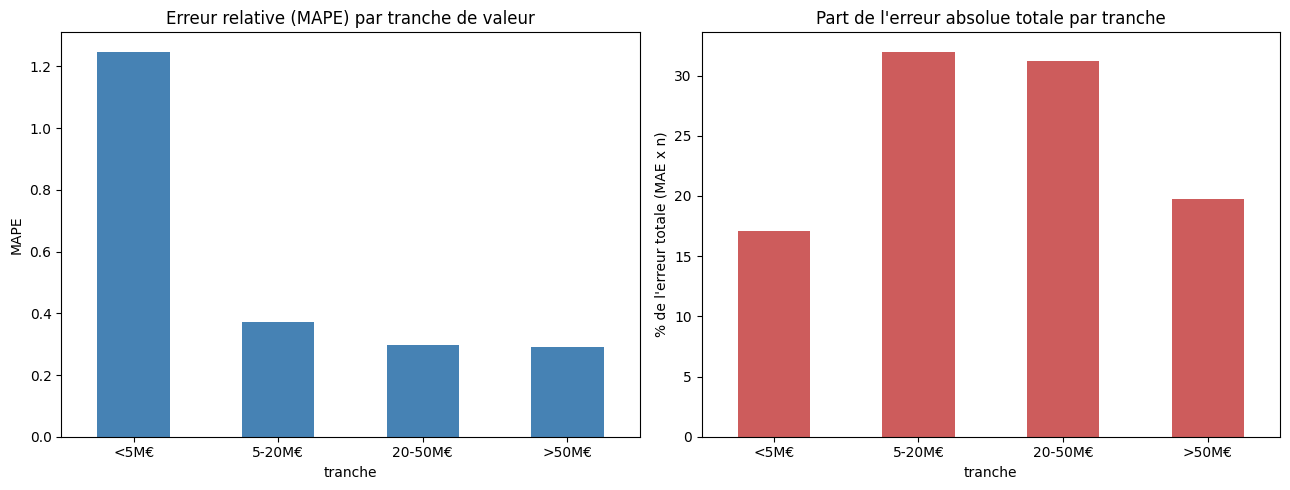

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

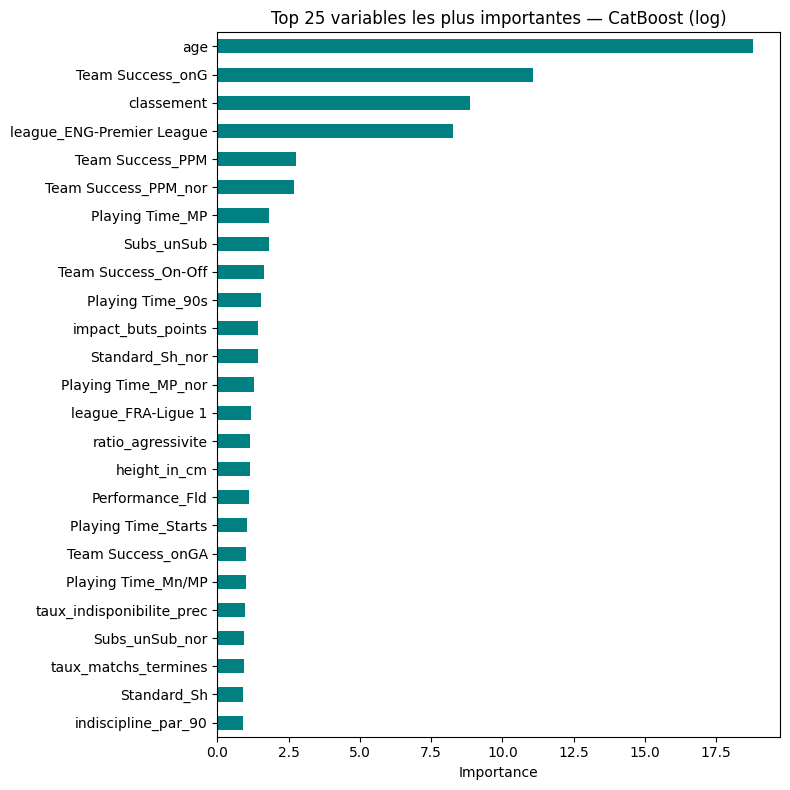

age                          18.803786
Team Success_onG             11.070084
classement                    8.860702
league_ENG-Premier League     8.280668
Team Success_PPM              2.767429
Team Success_PPM_nor          2.678684
Playing Time_MP               1.826005
Subs_unSub                    1.807208
Team Success_On-Off           1.625645
Playing Time_90s              1.539793
impact_buts_points            1.439947
Standard_Sh_nor               1.408787
Playing Time_MP_nor           1.293339
league_FRA-Ligue 1            1.171459
ratio_agressivite             1.130714
height_in_cm                  1.129734
Performance_Fld               1.089542
Playing Time_Starts           1.028906
Team Success_onGA             1.000903
Playing Time_Mn/MP            0.989148
taux_indisponibilite_prec     0.955058
Subs_unSub_nor                0.942748
taux_matchs_termines          0.938760
Standard_Sh                   0.906367
indiscipline_par_90           0.900015
dtype: float64


In [40]:
importances = pd.Series(
    modeles_tuned_log["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75   # augmenter à 100-150 pour de meilleurs résultats

## Chargement des données

In [10]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

## Feature engineering ciblé

On ajoute trois familles de features avant de construire X_train/X_val/X_test :

1. **`peak_distance`** : distance à l'âge de pic (25 ans). La relation âge/valeur est en cloche — `age` seul ne capte pas la symétrie.
2. **`age_sq`** : terme quadratique pour modéliser la courbure.

In [11]:
# Valeur marchande de la saison précédente (ANTI-LEAKAGE)


# On crée une base d'historique propre et triée par temps (sans toucher à tes df de split)
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)


df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_28232\2814531750.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_history["log_prev_value"] = np.log1p(


In [12]:
# Imputation des nouvelles variables (Ligue × Position)
# Les statistiques sont apprises uniquement sur le train

stats_xg = ["xg", "xa", "xg_buildup"]

# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)



# log_prev_value par Ligue ET Position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par Position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()

# xG par Ligue ET Position
xg_pos_league = {
    stat: (
        df_train_temp
        .groupby(["league_name", "position"])[stat]
        .median()
    )
    for stat in stats_xg
}

xg_global = {
    stat: df_train_temp[stat].median()
    for stat in stats_xg
}



def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index

    # log_prev_value
    

    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Étape B (Secours 1) : Par Position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Étape C (Secours 2) : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    # xG

    df_with_league.loc[df_with_league["position"] == "GK", stats_xg] = 0

    for stat in stats_xg:
        
        # Correction ici aussi : on ajoute .to_series(index=original_index)
        mapped_xg = (
            df_with_league.set_index(["league_name", "position"])
            .index.map(xg_pos_league[stat])
            .to_series(index=original_index)
        )
        df_with_league[stat] = df_with_league[stat].fillna(mapped_xg)

        # Secours globale
        df_with_league[stat] = df_with_league[stat].fillna(
            xg_global[stat]
        )

    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])



df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

In [ ]:
def ajouter_features(df):
    df = df.copy()

    # Distance au pic de carrière
    if "age" in df.columns:
        df["peak_distance"]   = (df["age"] - 25).abs()
        df["age_sq"]          = df["age"] ** 2
        df["is_prime"]        = ((df["age"] >= 24) & (df["age"] <= 28)).astype(int)

    # Ratio buts/minutes (évite l'effet volume)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"] / (df["Playing Time_90s"] + 0.01)

    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"] = df["Performance_Ast"] / (df["Playing Time_90s"] + 0.01)

    return df

df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

print("Features ajoutées :", [c for c in df_train.columns if c in [
    "peak_distance","age_sq","is_prime","buts_par_90","ast_par_90"
]])

Features ajoutées : ['peak_distance', 'age_sq', 'is_prime', 'buts_par_90', 'ast_par_90']


## Préparation des jeux X / y

In [14]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
# w_i = 1 / log1p(y_i)  → les joueurs à faible valeur pèsent autant que les stars
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7401, 147) | X_val : (2426, 147) | X_test : (2286, 147)


## Tuning Optuna — optimisation sur MAPE

On optimise directement le **MAPE** (erreur relative en %) plutôt que le MAE (erreur absolue en €).  
Pourquoi : le MAE pousse le modèle à bien prédire les grosses valeurs (qui pèsent plus en €), au détriment du MAPE sur les petites valeurs (< 5M€) qui représentent 47% du dataset.

In [15]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # RECOMMANDATION CLAUDE : On fait la prédiction en log
    preds_log = model.predict(X_val)
    
    # On calcule le RMSE directement sur les logs (y_val_log) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

print("--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

# Pour afficher un vrai MAPE business à la fin (calculé hors de la boucle) :
best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds = np.expm1(best_model.predict(X_val))
final_mape = mean_absolute_percentage_error(y_val, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---


  0%|          | 0/75 [00:06<?, ?it/s]

[W 2026-07-13 16:22:19,489] Trial 0 failed with parameters: {'n_estimators': 1250, 'max_depth': 10, 'learning_rate': 0.006318598359104425, 'subsample': 0.5446062880266449, 'colsample_bytree': 0.9627983128285522, 'min_child_weight': 5.228175246239128, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_28232\2569202356.py", line 22, in objective_xgb
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\xgboost\core.py", line 553, in inner_f
    return func(**kwargs)
  File "c:\Use

KeyboardInterrupt: 

In [ ]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # MODIFICATION : On reste en log pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val))
final_mape_lgbm = mean_absolute_percentage_error(y_val, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---


Best trial: 66. Best value: 0.527797: 100%|██████████| 75/75 [18:09<00:00, 14.53s/it]


Meilleur RMSE log val : 0.5278
MAPE réel correspondant : 0.4232
Params : {'n_estimators': 4500, 'num_leaves': 87, 'max_depth': 15, 'learning_rate': 0.005006711594724197, 'subsample': 0.8913885862122211, 'colsample_bytree': 0.5779274369614529, 'reg_alpha': 0.15092938948890988, 'reg_lambda': 0.00015428902796434742}


In [ ]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=(X_val, y_val_log),
        sample_weight=sample_weights_train,
        verbose=False
    )
    
    # MODIFICATION : On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train, y_train_log, sample_weight=sample_weights_train, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val))
final_mape_cat = mean_absolute_percentage_error(y_val, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 58. Best value: 0.53225: 100%|██████████| 75/75 [20:11<00:00, 16.16s/it] 


Meilleur RMSE log val : 0.5323
MAPE réel correspondant : 0.4257
Params : {'iterations': 2000, 'depth': 7, 'learning_rate': 0.021766268263905462, 'l2_leaf_reg': 3.344317070195929, 'subsample': 0.931778949956099}


## Modèles finaux & évaluation validation

In [ ]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("=== Évaluation VALIDATION ===")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

=== Évaluation VALIDATION ===
  XGBoost      | MAPE : 41.86% | MAE :    2,982,003 € | R² : 0.8918 | R²adj : 0.8848
  LightGBM     | MAPE : 42.32% | MAE :    3,020,821 € | R² : 0.8880 | R²adj : 0.8808
  CatBoost     | MAPE : 42.54% | MAE :    3,109,775 € | R² : 0.8834 | R²adj : 0.8759

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost   2.982003e+06  5.923658e+06  0.418577  0.891810   0.884829
LightGBM  3.020821e+06  6.027569e+06  0.423159  0.887981   0.880752
CatBoost  3.109775e+06  6.149455e+06  0.425368  0.883405   0.875881


## Stacking OOF (Out-Of-Fold)

Le méta-modèle apprend le meilleur poids à donner à chaque modèle de base à partir de prédictions **hors-échantillon** (OOF), générées par cross-validation sur le train.  
Cela évite la fuite de données du stacking naïf sur la validation.

Le méta-modèle est entraîné sur les prédictions OOF **en espace log** pour que les poids restent stables, puis les prédictions finales sont retransformées avec `expm1`.

In [ ]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# OOF sur le train (cv=5)
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# Prédictions val & test (modèles ré-entraînés sur tout le train)
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    3,077,723 € | OOF MAPE : 43.48%
  LightGBM     | OOF MAE :    3,066,871 € | OOF MAPE : 43.35%
  CatBoost     | OOF MAE :    3,071,096 € | OOF MAPE : 43.03%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [ ]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)

meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\nComparaison finale (Validation)")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.1766
  LightGBM     : 0.2433
  CatBoost     : 0.6015
  Intercept    : -0.3266

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 41.69% | MAE :    2,993,297 € | R² : 0.8960
  Moyenne simple  | MAPE : 41.63% | MAE :    2,968,003 € | R² : 0.8935


## Évaluation finale sur le TEST

In [ ]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 40.41% | MAE :    3,310,209 € | R² : 0.8865
  Moyenne simple  | MAPE : 40.20% | MAE :    3,256,333 € | R² : 0.8782
  XGBoost seul    | MAPE : 40.21% | MAE :    3,250,649 € | R² : 0.8723
  LightGBM seul   | MAPE : 40.83% | MAE :    3,297,659 € | R² : 0.8746
  CatBoost seul   | MAPE : 41.38% | MAE :    3,449,386 € | R² : 0.8719

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Moyenne simple  0.401966  3.256333e+06  0.878231   0.869858
XGBoost seul    0.402086  3.250649e+06  0.872253   0.863470
Stacking OOF    0.404136  3.310209e+06  0.886495   0.878691
LightGBM seul   0.408258  3.297659e+06  0.874559   0.865935
CatBoost seul   0.413751  3.449386e+06  0.871942   0.863137


## Analyse d'erreur par tranche de valeur

In [ ]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€          1067  2.428327e+06  9.179027e+05  0.543125  46.675416        12.942837
5–20M€         794  1.165050e+07  3.571842e+06  0.319606  34.733158        37.478413
20–50M€        343  3.234111e+07  6.819420e+06  0.216496  15.004374        30.910780
>50M€           82  8.414634e+07  1.722720e+07  0.198969   3.587052        18.667969


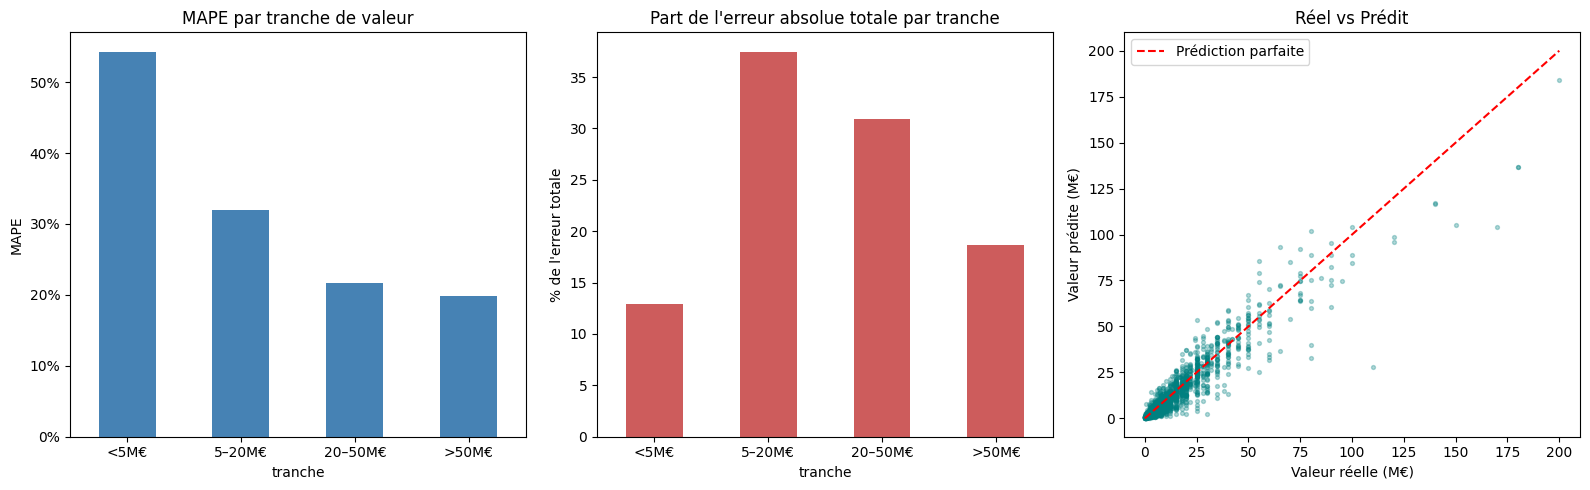

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 — % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 — Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Feature importance

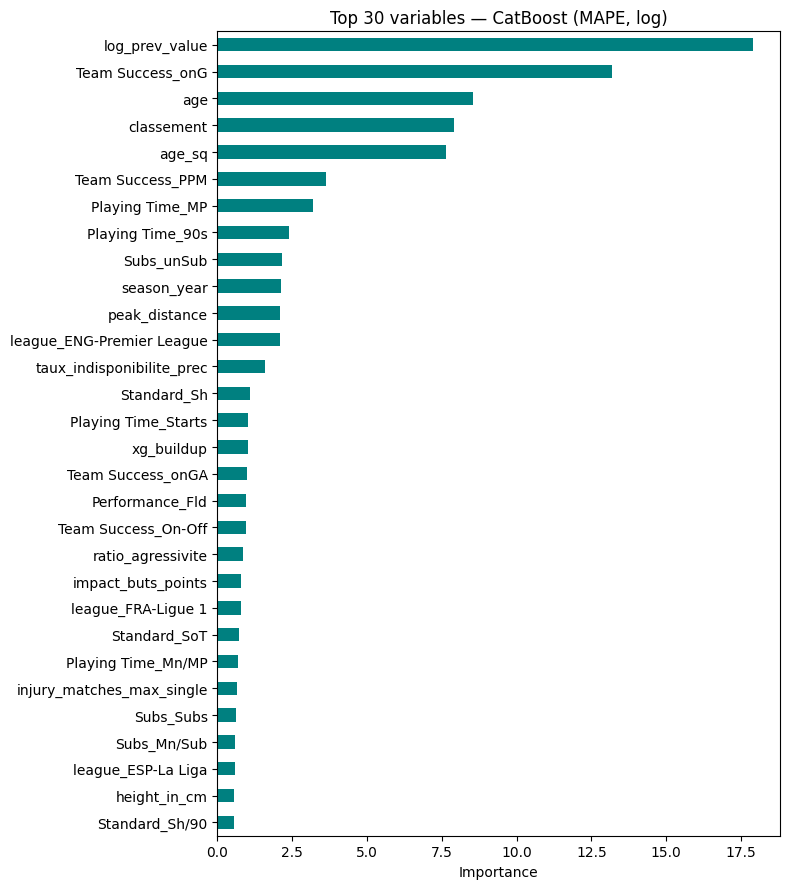


Top 30 :
log_prev_value               17.904967
Team Success_onG             13.182352
age                           8.527303
classement                    7.919110
age_sq                        7.625123
Team Success_PPM              3.639661
Playing Time_MP               3.181934
Playing Time_90s              2.374106
Subs_unSub                    2.153034
season_year                   2.130060
peak_distance                 2.105686
league_ENG-Premier League     2.100864
taux_indisponibilite_prec     1.594929
Standard_Sh                   1.103244
Playing Time_Starts           1.030358
xg_buildup                    1.021473
Team Success_onGA             0.976120
Performance_Fld               0.948499
Team Success_On-Off           0.936984
ratio_agressivite             0.856860
impact_buts_points            0.787836
league_FRA-Ligue 1            0.781740
Standard_SoT                  0.703358
Playing Time_Mn/MP            0.701608
injury_matches_max_single     0.645643
Subs_Subs      

In [ ]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

# Inférence statistique (RETRAIT DES OUTLIERS)

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75   # augmenter à 100-150 pour de meilleurs résultats

## Chargement des données

In [ ]:
df_train_initial = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val_initial   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test_initial  = pd.read_csv("../data_finale/featuring/test_featured.csv")

# Calcul des quartiles et de l'IQR uniquement sur le TRAIN
Q1 = df_train_initial['market_value_in_eur'].quantile(0.25)
Q3 = df_train_initial['market_value_in_eur'].quantile(0.75)
IQR = Q3 - Q1

# Définition du seuil supérieur uniquement
# (Pas besoin de seuil inférieur puisqu'on garde tout ce qui est petit)
seuil_superieur = Q3 + 1.5 * IQR

# Filtrage : on ne garde que ce qui est INFÉRIEUR ou ÉGAL au seuil maximum
df_train = df_train_initial[df_train_initial['market_value_in_eur'] <= seuil_superieur]
df_val   = df_val_initial[df_val_initial['market_value_in_eur'] <= seuil_superieur]
df_test  = df_test_initial[df_test_initial['market_value_in_eur'] <= seuil_superieur]

# Vérification du nombre de lignes supprimées
print(f"Seuil max appliqué : {seuil_superieur:.2f}")
print(f"Lignes supprimées dans Train : {len(df_train_initial) - len(df_train)}")
print(f"Lignes supprimées dans Val   : {len(df_val_initial) - len(df_val)}")
print(f"Lignes supprimées dans Test  : {len(df_test_initial) - len(df_test)}")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

Seuil max appliqué : 32000000.00
Lignes supprimées dans Train : 570
Lignes supprimées dans Val   : 224
Lignes supprimées dans Test  : 216


In [18]:
df_train

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,taux_indisponibilite,taux_indisponibilite_prec,fragilite_chronique,score_hype_nation,impact_buts_points,indiscipline_par_90,ratio_buts_hors_penalty,ratio_buts_penalty,est_polyvalent,taux_matchs_termines
0,Aaron Connolly,Brighton,IRL,20,17,9,8.8,2,1,2,...,0.205479,0.000000,0,0,0.103529,0.000000,1.0,0.0,1,0.111111
1,Aaron Cresswell,West Ham United,ENG,31,36,36,35.2,0,8,0,...,0.030137,0.000000,0,7,0.000000,0.085227,0.0,0.0,0,0.944444
2,Aaron Cresswell,West Ham United,ENG,32,31,31,30.3,2,3,2,...,0.000000,0.030137,0,6,0.093548,0.099010,1.0,0.0,0,0.935484
3,Aaron Cresswell,West Ham United,ENG,33,28,24,24.8,0,1,0,...,0.000000,0.000000,0,7,0.000000,0.120968,0.0,0.0,0,0.833333
4,Aaron Hickey,Bologna,SCO,18,11,10,8.4,0,0,0,...,0.317808,0.000000,0,0,0.000000,1.071429,0.0,0.0,1,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7396,Šime Vrsaljko,Atlético Madrid,CRO,28,9,6,5.8,0,0,0,...,0.000000,0.000000,0,0,0.000000,0.344828,0.0,0.0,0,0.500000
7397,Šime Vrsaljko,Atlético Madrid,CRO,29,21,10,10.2,1,2,1,...,0.594521,0.000000,0,0,0.088571,0.392157,1.0,0.0,1,0.400000
7398,Ștefan Radu,Lazio,ROU,34,31,30,27.3,0,3,0,...,0.172603,0.000000,0,0,0.000000,0.073260,0.0,0.0,0,0.633333
7399,Ștefan Radu,Lazio,ROU,35,10,6,6.2,0,0,0,...,0.131507,0.172603,0,0,0.000000,0.322581,0.0,0.0,0,0.500000


## Feature engineering ciblé

On ajoute trois familles de features avant de construire X_train/X_val/X_test :

1. **`peak_distance`** : distance à l'âge de pic (27 ans). La relation âge/valeur est en cloche — `age` seul ne capte pas la symétrie.
2. **`age_sq`** : terme quadratique pour modéliser la courbure.

In [19]:
# Valeur marchande de la saison précédente (ANTI-LEAKAGE)


# On crée une base d'historique propre et triée par temps (sans toucher à tes df de split)
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)


df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_28232\2814531750.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_history["log_prev_value"] = np.log1p(


In [20]:
# Imputation des nouvelles variables (Ligue × Position)
# Les statistiques sont apprises uniquement sur le train

stats_xg = ["xg", "xa", "xg_buildup"]

# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)



# log_prev_value par Ligue ET Position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par Position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()

# xG par Ligue ET Position
xg_pos_league = {
    stat: (
        df_train_temp
        .groupby(["league_name", "position"])[stat]
        .median()
    )
    for stat in stats_xg
}

xg_global = {
    stat: df_train_temp[stat].median()
    for stat in stats_xg
}



def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index

    # log_prev_value
    

    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Étape B (Secours 1) : Par Position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Étape C (Secours 2) : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    # xG

    df_with_league.loc[df_with_league["position"] == "GK", stats_xg] = 0

    for stat in stats_xg:
        
        # Correction ici aussi : on ajoute .to_series(index=original_index)
        mapped_xg = (
            df_with_league.set_index(["league_name", "position"])
            .index.map(xg_pos_league[stat])
            .to_series(index=original_index)
        )
        df_with_league[stat] = df_with_league[stat].fillna(mapped_xg)

        # Secours globale
        df_with_league[stat] = df_with_league[stat].fillna(
            xg_global[stat]
        )

    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])



df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

In [21]:
def ajouter_features(df):
    df = df.copy()

    # Distance au pic de carrière
    if "age" in df.columns:
        df["peak_distance"]   = (df["age"] - 27).abs()
        df["age_sq"]          = df["age"] ** 2
        df["is_prime"]        = ((df["age"] >= 24) & (df["age"] <= 28)).astype(int)

    # Ratio buts/minutes (évite l'effet volume)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"] / (df["Playing Time_90s"] + 0.01)

    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"] = df["Performance_Ast"] / (df["Playing Time_90s"] + 0.01)

    return df

df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

print("Features ajoutées :", [c for c in df_train.columns if c in [
    "peak_distance","age_sq","is_prime","buts_par_90","ast_par_90"
]])

Features ajoutées : ['peak_distance', 'age_sq', 'is_prime', 'buts_par_90', 'ast_par_90']


## Préparation des jeux X / y

In [22]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
# w_i = 1 / log1p(y_i)  → les joueurs à faible valeur pèsent autant que les stars
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (6831, 147) | X_val : (2202, 147) | X_test : (2070, 147)


## Tuning Optuna — optimisation sur MAPE

On optimise directement le **MAPE** (erreur relative en %) plutôt que le MAE (erreur absolue en €).  
Pourquoi : le MAE pousse le modèle à bien prédire les grosses valeurs (qui pèsent plus en €), au détriment du MAPE sur les petites valeurs (< 5M€) qui représentent 47% du dataset.

In [23]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # RECOMMANDATION CLAUDE : On fait la prédiction en log
    preds_log = model.predict(X_val)
    
    # On calcule le RMSE directement sur les logs (y_val_log) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

print("--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

# Pour afficher un vrai MAPE business à la fin (calculé hors de la boucle) :
best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds = np.expm1(best_model.predict(X_val))
final_mape = mean_absolute_percentage_error(y_val, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 25. Best value: 0.54879: 100%|██████████| 75/75 [25:35<00:00, 20.47s/it] 


Meilleur RMSE log val : 0.5488
MAPE réel correspondant : 0.4440
Params : {'n_estimators': 2750, 'max_depth': 8, 'learning_rate': 0.009669186121398868, 'subsample': 0.903213766394549, 'colsample_bytree': 0.7948586138487902, 'min_child_weight': 0.5778243865945711, 'reg_alpha': 0.13114634549379592, 'reg_lambda': 0.0033977225431707247}


In [24]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # MODIFICATION : On reste en log pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val))
final_mape_lgbm = mean_absolute_percentage_error(y_val, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---


Best trial: 74. Best value: 0.552178: 100%|██████████| 75/75 [17:38<00:00, 14.11s/it]


Meilleur RMSE log val : 0.5522
MAPE réel correspondant : 0.4426
Params : {'n_estimators': 2000, 'num_leaves': 112, 'max_depth': 9, 'learning_rate': 0.00739477470586159, 'subsample': 0.7454874844949122, 'colsample_bytree': 0.6213466961802402, 'reg_alpha': 0.00022305560805691726, 'reg_lambda': 0.00038641439644338584}


In [25]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=(X_val, y_val_log),
        sample_weight=sample_weights_train,
        verbose=False
    )
    
    # MODIFICATION : On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train, y_train_log, sample_weight=sample_weights_train, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val))
final_mape_cat = mean_absolute_percentage_error(y_val, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 29. Best value: 0.549728: 100%|██████████| 75/75 [19:21<00:00, 15.48s/it]


Meilleur RMSE log val : 0.5497
MAPE réel correspondant : 0.4440
Params : {'iterations': 2500, 'depth': 7, 'learning_rate': 0.019958469433499625, 'l2_leaf_reg': 3.1745283596300227, 'subsample': 0.9677162945201735}


## Modèles finaux & évaluation validation

In [26]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("=== Évaluation VALIDATION ===")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

=== Évaluation VALIDATION ===
  XGBoost      | MAPE : 44.40% | MAE :    2,260,195 € | R² : 0.7416 | R²adj : 0.7231
  LightGBM     | MAPE : 44.26% | MAE :    2,253,504 € | R² : 0.7446 | R²adj : 0.7263
  CatBoost     | MAPE : 44.40% | MAE :    2,264,197 € | R² : 0.7445 | R²adj : 0.7263

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
LightGBM  2.253504e+06  3.845911e+06  0.442634  0.744617   0.726340
XGBoost   2.260195e+06  3.868522e+06  0.443995  0.741606   0.723113
CatBoost  2.264197e+06  3.846512e+06  0.444043  0.744538   0.726255


## Stacking OOF (Out-Of-Fold)

Le méta-modèle apprend le meilleur poids à donner à chaque modèle de base à partir de prédictions **hors-échantillon** (OOF), générées par cross-validation sur le train.  
Cela évite la fuite de données du stacking naïf sur la validation.

Le méta-modèle est entraîné sur les prédictions OOF **en espace log** pour que les poids restent stables, puis les prédictions finales sont retransformées avec `expm1`.

In [27]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# OOF sur le train (cv=5)
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# Prédictions val & test (modèles ré-entraînés sur tout le train)
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    2,262,797 € | OOF MAPE : 45.15%
  LightGBM     | OOF MAE :    2,243,483 € | OOF MAPE : 45.10%
  CatBoost     | OOF MAE :    2,223,850 € | OOF MAPE : 44.29%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [28]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)

meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\nComparaison finale (Validation)")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.2931
  LightGBM     : 0.0594
  CatBoost     : 0.6715
  Intercept    : -0.3624

Comparaison finale (Validation)
  Stacking OOF    | MAPE : 43.67% | MAE :    2,211,418 € | R² : 0.7567
  Moyenne simple  | MAPE : 43.79% | MAE :    2,225,361 € | R² : 0.7498


## Évaluation finale sur le TEST

In [29]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 41.95% | MAE :    2,449,081 € | R² : 0.7514
  Moyenne simple  | MAPE : 42.14% | MAE :    2,460,837 € | R² : 0.7475
  XGBoost seul    | MAPE : 42.77% | MAE :    2,486,003 € | R² : 0.7428
  LightGBM seul   | MAPE : 42.83% | MAE :    2,493,515 € | R² : 0.7452
  CatBoost seul   | MAPE : 42.72% | MAE :    2,516,764 € | R² : 0.7360

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Stacking OOF    0.419537  2.449081e+06  0.751399   0.732385
Moyenne simple  0.421420  2.460837e+06  0.747451   0.728135
CatBoost seul   0.427152  2.516764e+06  0.736032   0.715843
XGBoost seul    0.427658  2.486003e+06  0.742826   0.723157
LightGBM seul   0.428282  2.493515e+06  0.745201   0.725713


## Analyse d'erreur par tranche de valeur

In [30]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€          1067  2.428327e+06  9.244191e+05  0.538669  51.545894        19.456282
5–20M€         794  1.165050e+07  3.303667e+06  0.301927  38.357488        51.742009
20–50M€        209  2.655024e+07  6.986271e+06  0.258143  10.096618        28.801709


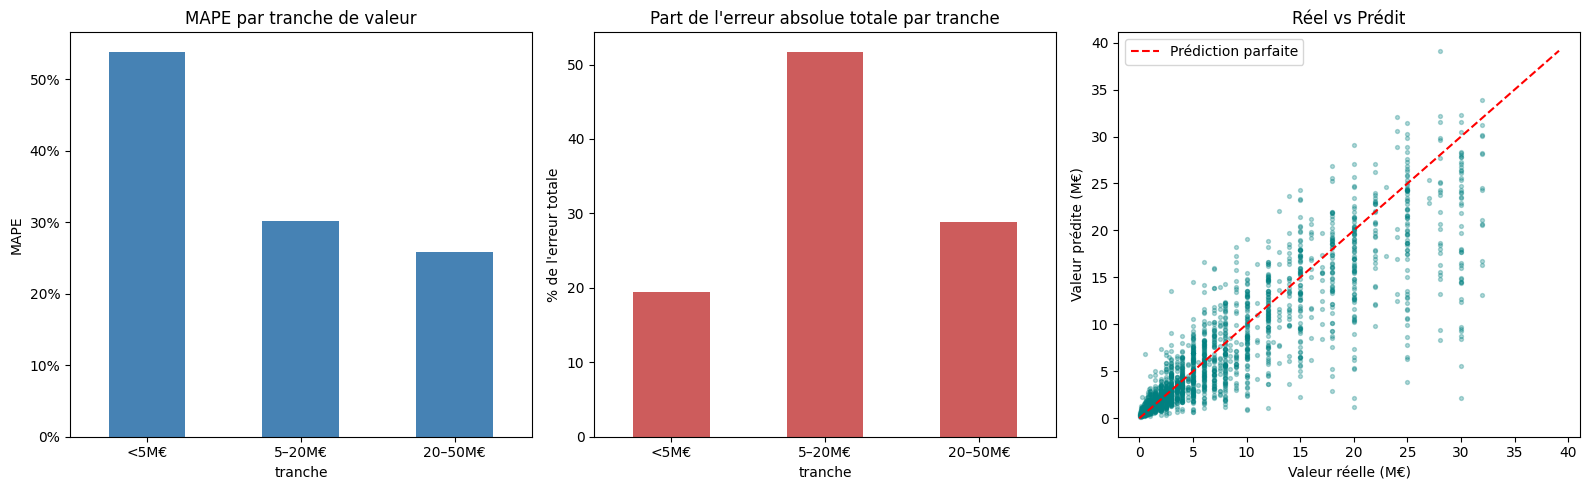

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 — % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 — Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Feature importance

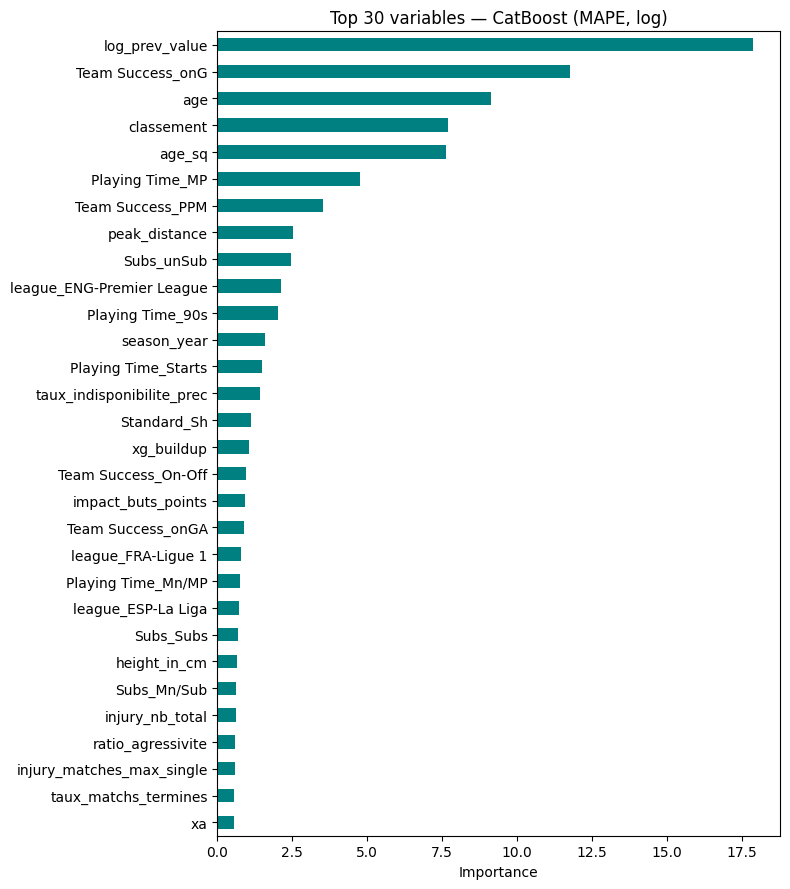


Top 30 :
log_prev_value               17.888747
Team Success_onG             11.768841
age                           9.149863
classement                    7.709916
age_sq                        7.634872
Playing Time_MP               4.749310
Team Success_PPM              3.525531
peak_distance                 2.517221
Subs_unSub                    2.462761
league_ENG-Premier League     2.115631
Playing Time_90s              2.007248
season_year                   1.578286
Playing Time_Starts           1.503298
taux_indisponibilite_prec     1.428666
Standard_Sh                   1.110498
xg_buildup                    1.049731
Team Success_On-Off           0.965203
impact_buts_points            0.930274
Team Success_onGA             0.882837
league_FRA-Ligue 1            0.785176
Playing Time_Mn/MP            0.767408
league_ESP-La Liga            0.712806
Subs_Subs                     0.676531
height_in_cm                  0.660178
Subs_Mn/Sub                   0.607549
injury_nb_total

In [32]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

# Réduction de dimensionnalité — ACP & Sélection de variables

**Objectif :** tester si réduire le nombre de variables avant la modélisation améliore les performances par rapport à la v4 (baseline : MAPE test = 38.57%, R² = 0.880).

**Trois approches testées :**
1. **ACP** (Analyse en Composantes Principales) — transformation linéaire non supervisée
2. **Sélection par importance** (SelectFromModel) — on garde les N features les plus importantes selon XGBoost
3. **Sélection par permutation** (RFECV) — sélection récursive basée sur la permutation importance, non biaisée pour les arbres

À la fin, on compare les 3 approches + la v4 sans réduction sur les mêmes métriques.

## Imports & configuration

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75

## Chargement & feature engineering (identique v4)

In [72]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

for df in [df_train, df_val, df_test]:
    df.dropna(subset=[colonne_cible], inplace=True)

# ── log_prev_value (anti-leakage) ────────────────────────────────────────────
df_history = pd.concat([df_train, df_val, df_test], axis=0).sort_values(["player","season_year"])
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1))

df_train = df_history[df_history["season_year"].isin([2020,2021,2022])].copy()
df_val   = df_history[df_history["season_year"].isin([2023])].copy()
df_test  = df_history[df_history["season_year"].isin([2024])].copy()

# ── Imputation xG ─────────────────────────────────────────────────────────────
league_cols = [c for c in df_train.columns if c.startswith("league_")]
def extraire_ligue(df):
    df = df.copy()
    df["_ligue"] = "Other"
    for col in league_cols:
        df.loc[df[col]==1, "_ligue"] = col.replace("league_","")
    return df

stats_xg = ["xg","xa","xg_buildup"]
for col in stats_xg:
    if col not in df_train.columns: continue
    medians = (df_train.pipe(extraire_ligue)
               .groupby(["pos_GK","_ligue"])[col].median())
    def impute(df, col, medians):
        df = df.pipe(extraire_ligue)
        df[col] = df.apply(
            lambda r: medians.get((r["pos_GK"], r["_ligue"]),
                                  df_train[col].median())
            if pd.isna(r[col]) else r[col], axis=1)
        return df
    df_train = impute(df_train, col, medians)
    df_val   = impute(df_val,   col, medians)
    df_test  = impute(df_test,  col, medians)

# Imputation log_prev_value
def impute_log_prev(df_train, df_target):
    df_target = df_target.copy()
    mask_nan = df_target["log_prev_value"].isna()
    if mask_nan.sum() == 0: return df_target
    medians_prev = df_train.groupby("pos_GK")["log_prev_value"].median()
    df_target.loc[mask_nan, "log_prev_value"] = df_target.loc[mask_nan,"pos_GK"].map(medians_prev)
    df_target["log_prev_value"].fillna(df_train["log_prev_value"].median(), inplace=True)
    return df_target

df_train = impute_log_prev(df_train, df_train)
df_val   = impute_log_prev(df_train, df_val)
df_test  = impute_log_prev(df_train, df_test)

# ── Features d'âge & ratios ───────────────────────────────────────────────────
def ajouter_features(df):
    df = df.copy()
    if "age" in df.columns:
        df["peak_distance"] = (df["age"]-27).abs()
        df["age_sq"]        = df["age"]**2
        df["is_prime"]      = ((df["age"]>=24)&(df["age"]<=28)).astype(int)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"]/(df["Playing Time_90s"]+0.01)
    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"]  = df["Performance_Ast"]/(df["Playing Time_90s"]+0.01)
    return df

df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

# ── X / y ─────────────────────────────────────────────────────────────────────
# FIX : on filtre cols_a_supprimer aux colonnes qui existent réellement dans le df
# pour éviter le KeyError si market_value_in_eur_nor a déjà été supprimée avec _nor
cols_candidats = [colonne_cible, colonne_joueur, colonne_team,
                  colonne_nation, "position", "market_value_in_eur_nor"]
cols_a_supprimer = [c for c in cols_candidats if c in df_train.columns]

colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]
for d in [df_train, df_val, df_test]:
    d.drop(columns=colonnes_nor, errors="ignore", inplace=True)
    if "_ligue" in d.columns: d.drop(columns=["_ligue"], inplace=True)

# Re-filtrer après suppression des _nor (certaines peuvent avoir disparu)
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]
X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]
X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

sample_weights = 1/np.log1p(y_train)
sample_weights = sample_weights/sample_weights.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")
print(f"Colonnes supprimées : {cols_a_supprimer}")
print(f"Colonnes _nor supprimées : {len(colonnes_nor)}")

X_train : (7401, 147) | X_val : (2426, 147) | X_test : (2286, 147)
Colonnes supprimées : ['market_value_in_eur', 'player', 'team', 'nation', 'position']
Colonnes _nor supprimées : 24


## Baseline — modèle de référence sans réduction

On commence par enregistrer les performances du meilleur modèle (Stacking OOF XGB+LGBM+CAT) pour pouvoir comparer.

In [ ]:
def rmse_log(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred,0,None))))

def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rl       = rmse_log(y_true, y_pred)
    n, p_    = len(y_true), 1
    return {"Label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape,
            "R²": r2, "RMSE_log": rl}

def entrainer_stack(X_tr, y_tr_log, X_val_, y_val_log_, X_te, y_val, w=None):
    """Entraîne XGB+LGBM+CAT + stacking OOF. Renvoie preds_val, preds_test."""
    xgb = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        tree_method="hist", enable_categorical=True,
                        objective="reg:squarederror",
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    lgbm = LGBMRegressor(n_estimators=1000, num_leaves=63, max_depth=6,
                          learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    cat  = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                              l2_leaf_reg=3, bootstrap_type="Bernoulli",
                              random_state=RANDOM_STATE, verbose=0)
    modeles = {"XGBoost": xgb, "LightGBM": lgbm, "CatBoost": cat}
    kw = {"sample_weight": w} if w is not None else {}

    # OOF
    oof = {}
    for nom, m in modeles.items():
        oof[nom] = cross_val_predict(m, X_tr, y_tr_log, cv=5, n_jobs=-1)

    # Ré-entraînement
    for nom, m in modeles.items():
        if isinstance(m, CatBoostRegressor):
            m.fit(X_tr, y_tr_log, eval_set=(X_val_, y_val_log_), verbose=False, **kw)
        else:
            m.fit(X_tr, y_tr_log, **kw)

    X_meta_tr  = pd.DataFrame(oof)
    X_meta_val = pd.DataFrame({n: m.predict(X_val_) for n,m in modeles.items()})
    X_meta_te  = pd.DataFrame({n: m.predict(X_te)  for n,m in modeles.items()})

    meta = LinearRegression(positive=True)
    meta.fit(X_meta_tr, y_tr_log)

    return (np.expm1(meta.predict(X_meta_val)),
            np.expm1(meta.predict(X_meta_te)),
            modeles)

print("Entraînement baseline (sans réduction)...")
pred_val_base, pred_test_base, modeles_base = entrainer_stack(
    X_train, y_train_log, X_val, y_val_log, X_test, y_val, w=sample_weights)

res_base = evaluer_complet("Sans réduction", y_test, pred_test_base)
print(f"  MAPE : {res_base['MAPE']:.2%} | R² : {res_base['R²']:.4f} | RMSE_log : {res_base['RMSE_log']:.4f}")
resultats_comparaison = [res_base]

Entraînement baseline (v4, sans réduction)...
  MAPE : 40.24% | R² : 0.8790 | RMSE_log : 0.5097


## Approche 1 — ACP (Analyse en Composantes Principales)

**Principe :** l'ACP transforme les features originales en composantes orthogonales (non corrélées) classées par variance expliquée. On garde le nombre de composantes qui expliquent 95% de la variance totale.

**Avantage :** élimine la multicolinéarité (tes features binaires de ligue, position, confédération sont très corrélées entre elles).  
**Inconvénient :** les composantes ne sont plus interprétables — on ne peut plus dire "cette feature est importante".  
**Obligation :** l'ACP nécessite une standardisation préalable (StandardScaler), sinon les features en grandes unités (minutes jouées, buts) dominent arbitrairement les premières composantes.

NaN restants — train: 0 | val: 0 | test: 0
Dimensions originales : 147 features
Composantes pour 95%  de variance : 80
Composantes pour 99%  de variance : 105
Composantes pour 99.9% de variance : 121


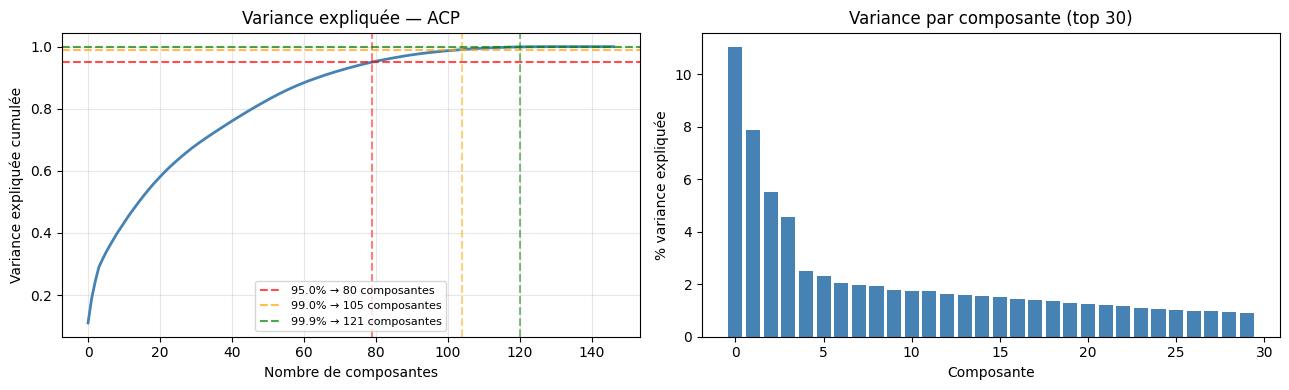

In [74]:
from sklearn.impute import SimpleImputer

# Imputation des NaN résiduels (médiane par colonne, apprise sur le train)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"NaN restants — train: {X_train_imp.isnull().sum().sum()} | val: {X_val_imp.isnull().sum().sum()} | test: {X_test_imp.isnull().sum().sum()}")

# Standardisation obligatoire avant ACP
scaler_acp = StandardScaler()
X_train_scaled = scaler_acp.fit_transform(X_train_imp)
X_val_scaled   = scaler_acp.transform(X_val_imp)
X_test_scaled  = scaler_acp.transform(X_test_imp)

# ACP — on cherche le nombre de composantes pour 95% de variance expliquée
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_)
n_95  = np.argmax(variance_cumul >= 0.95) + 1
n_99  = np.argmax(variance_cumul >= 0.99) + 1
n_999 = np.argmax(variance_cumul >= 0.999) + 1

print(f"Dimensions originales : {X_train.shape[1]} features")
print(f"Composantes pour 95%  de variance : {n_95}")
print(f"Composantes pour 99%  de variance : {n_99}")
print(f"Composantes pour 99.9% de variance : {n_999}")

# Visualisation de la variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(variance_cumul, lw=2, color="steelblue")
for thresh, n, color in [(0.95, n_95, "red"), (0.99, n_99, "orange"), (0.999, n_999, "green")]:
    axes[0].axhline(thresh, linestyle="--", color=color, alpha=0.7,
                     label=f"{thresh:.1%} → {n} composantes")
    axes[0].axvline(n-1, linestyle="--", color=color, alpha=0.5)
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance expliquée cumulée")
axes[0].set_title("Variance expliquée — ACP")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Variance par composante (top 30)
axes[1].bar(range(30), pca_full.explained_variance_ratio_[:30]*100,
             color="steelblue", edgecolor="none")
axes[1].set_xlabel("Composante")
axes[1].set_ylabel("% variance expliquée")
axes[1].set_title("Variance par composante (top 30)")
plt.tight_layout()
plt.show()

In [75]:
# Test avec 3 seuils de variance : 95%, 99%, 99.9%
for seuil, n_comp, label_acp in [
    (0.95,  n_95,  "ACP 95%"),
    (0.99,  n_99,  "ACP 99%"),
    (0.999, n_999, "ACP 99.9%"),
]:
    print(f"\n--- {label_acp} ({n_comp} composantes) ---")
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr_pca  = pca.fit_transform(X_train_scaled)
    Xval_pca = pca.transform(X_val_scaled)
    Xte_pca  = pca.transform(X_test_scaled)

    # Convertir en DataFrame pour compatibilité (les arbres n'ont pas besoin de noms)
    Xtr_pca  = pd.DataFrame(Xtr_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])
    Xval_pca = pd.DataFrame(Xval_pca, columns=[f"PC{i+1}" for i in range(n_comp)])
    Xte_pca  = pd.DataFrame(Xte_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])

    # y_val_log doit être réindexé
    y_val_log_arr = y_val_log.values

    pred_val_acp, pred_te_acp, _ = entrainer_stack(
        Xtr_pca, y_train_log.values, Xval_pca,
        pd.Series(y_val_log_arr), Xte_pca, y_val,
        w=sample_weights.values
    )
    res = evaluer_complet(label_acp, y_test.values, pred_te_acp)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- ACP 95% (80 composantes) ---
  MAPE : 57.07% | R² : 0.7883 | RMSE_log : 0.6047

--- ACP 99% (105 composantes) ---
  MAPE : 58.95% | R² : 0.7806 | RMSE_log : 0.6139

--- ACP 99.9% (121 composantes) ---
  MAPE : 58.50% | R² : 0.7783 | RMSE_log : 0.6125


## Approche 2 — Sélection par importance XGBoost (SelectFromModel)

**Principe :** on entraîne un XGBoost rapide, on récupère l'importance de chaque feature (gain), et on garde seulement celles dont l'importance dépasse un seuil.

**Avantage :** garde les features originales interprétables, réduit le bruit.  
**Limite :** l'importance par gain (impureté) est biaisée pour les features à haute cardinalité — c'est pourquoi on teste aussi la permutation importance ci-dessous.

Features total : 147
Features avec importance > 0   : 139
Features avec importance > 0.01 (1%) : 12
Features avec importance > 0.005 (0.5%) : 28
Top 20 features :
Team Success_onG             0.193676
log_prev_value               0.140192
league_ENG-Premier League    0.104637
classement                   0.042827
impact_buts_points           0.032859
Standard_Sh                  0.030375
age                          0.026972
Standard_SoT                 0.017944
league_FRA-Ligue 1           0.017446
injury_nb_total              0.012658
confederation_CONMEBOL       0.010692
injury_matches_max_single    0.010257
Team Success_PPM             0.009079
peak_distance                0.008893
sub_position_Right-Back      0.008551
is_prime                     0.008292
season_year                  0.007802
league_ESP-La Liga           0.007630
pos_GK                       0.007562
Subs_unSub                   0.007467


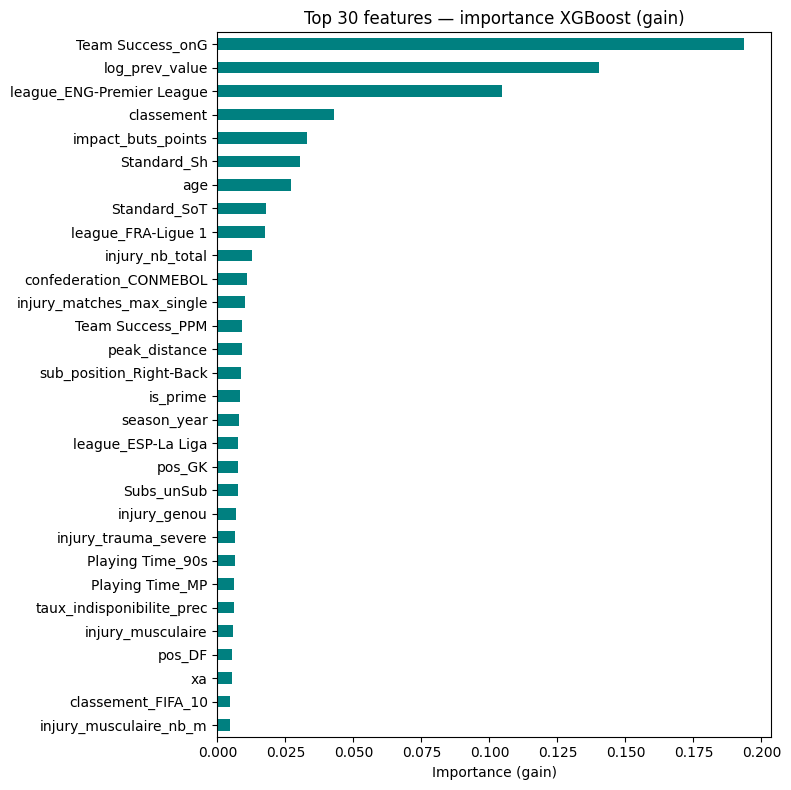

In [76]:
# Entraîner un XGBoost rapide pour obtenir les importances
selector_model = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
selector_model.fit(X_train, y_train_log, sample_weight=sample_weights)

importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(f"Features total : {len(importances)}")
print(f"Features avec importance > 0   : {(importances > 0).sum()}")
print(f"Features avec importance > 0.01 (1%) : {(importances > 0.01).sum()}")
print(f"Features avec importance > 0.005 (0.5%) : {(importances > 0.005).sum()}")
print(f"Top 20 features :")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(30).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="none")
ax.set_title("Top 30 features — importance XGBoost (gain)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

In [77]:
# Tester plusieurs seuils de sélection
for seuil_n, label_sfm in [(50, "SFM top 50"), (75, "SFM top 75"), (100, "SFM top 100")]:
    features_sel = importances.head(seuil_n).index.tolist()
    print(f"\n--- {label_sfm} ({len(features_sel)} features) ---")

    pred_val_sfm, pred_te_sfm, _ = entrainer_stack(
        X_train[features_sel], y_train_log, X_val[features_sel], y_val_log,
        X_test[features_sel], y_val, w=sample_weights
    )
    res = evaluer_complet(label_sfm, y_test, pred_te_sfm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- SFM top 50 (50 features) ---
  MAPE : 40.45% | R² : 0.8728 | RMSE_log : 0.5100

--- SFM top 75 (75 features) ---
  MAPE : 40.69% | R² : 0.8867 | RMSE_log : 0.5112

--- SFM top 100 (100 features) ---
  MAPE : 40.35% | R² : 0.8806 | RMSE_log : 0.5129


## Approche 3 — Sélection par Permutation Importance

**Principe :** on entraîne le modèle, puis on mélange aléatoirement une feature à la fois et on mesure la dégradation de performance. Si mélanger une feature ne dégrade pas le modèle, c'est qu'elle est inutile.

Calcul permutation importance (peut prendre 2-3 minutes)...

Features avec permutation importance > 0   : 94
Features avec permutation importance < 0   : 42 (mélanger améliore → bruit)

Top 30 permutation importance :
log_prev_value                   0.735071
age                              0.390254
Team Success_onG                 0.271809
league_ENG-Premier League        0.109576
classement                       0.082339
Team Success_onGA                0.027589
Standard_Sh                      0.025553
Subs_unSub                       0.015704
impact_buts_points               0.014234
Playing Time_MP                  0.013059
Playing Time_90s                 0.012142
Playing Time_Starts              0.011416
Team Success_PPM                 0.011096
league_FRA-Ligue 1               0.009947
Performance_Int                  0.008502
Performance_TklW                 0.006265
peak_distance                    0.005633
Team Success_On-Off              0.005261
taux_matchs_termines      

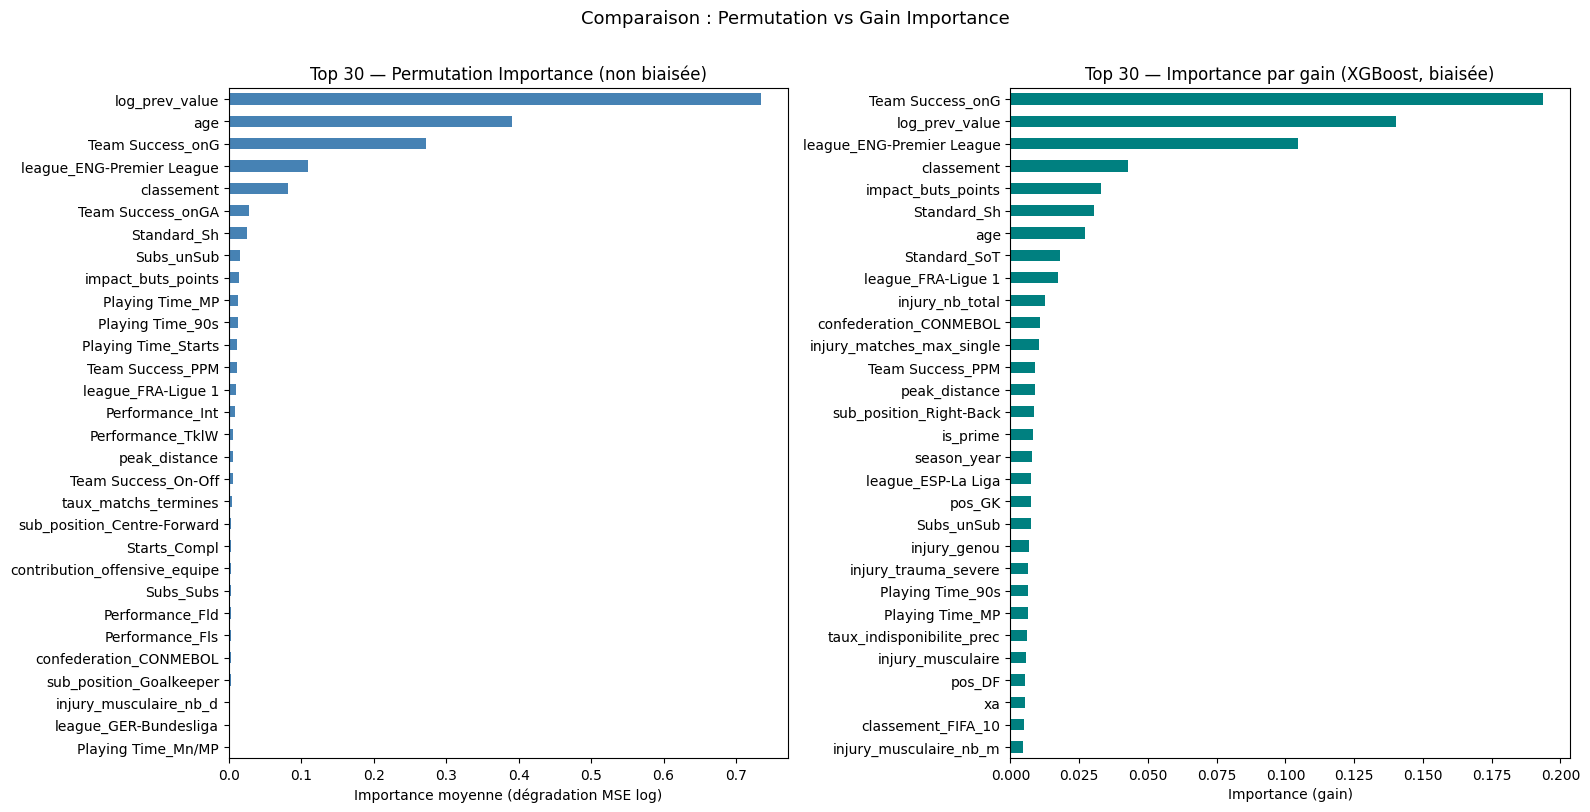

In [78]:
# Calculer la permutation importance sur le jeu de VALIDATION
# (sur le train on surestimerait l'importance car les arbres ont mémorisé le train)
print("Calcul permutation importance (peut prendre 2-3 minutes)...")

perm_result = permutation_importance(
    selector_model, X_val, y_val_log,
    n_repeats=10,           # 10 permutations par feature → estimation stable
    random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=X_train.columns)
perm_std = pd.Series(perm_result.importances_std,  index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

print(f"\nFeatures avec permutation importance > 0   : {(perm_imp > 0).sum()}")
print(f"Features avec permutation importance < 0   : {(perm_imp < 0).sum()} (mélanger améliore → bruit)")
print(f"\nTop 30 permutation importance :")
print(perm_imp.head(30).to_string())

# Comparaison gain vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

perm_imp.head(30).sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Top 30 — Permutation Importance (non biaisée)")
axes[0].set_xlabel("Importance moyenne (dégradation MSE log)")

importances.head(30).sort_values().plot(kind="barh", ax=axes[1], color="teal", edgecolor="none")
axes[1].set_title("Top 30 — Importance par gain (XGBoost, biaisée)")
axes[1].set_xlabel("Importance (gain)")

plt.suptitle("Comparaison : Permutation vs Gain Importance", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [79]:
# Sélection sur la base de la permutation importance
# On garde uniquement les features avec importance > 0 (mélanger les dégrade vraiment)
for seuil_perm, label_perm in [
    (0,    "Perm > 0  (toutes utiles)"),
    (0.001,"Perm > 0.001"),
    (0.005,"Perm > 0.005"),
]:
    features_perm = perm_imp[perm_imp > seuil_perm].index.tolist()
    if len(features_perm) < 5:
        print(f"Trop peu de features ({len(features_perm)}) pour seuil {seuil_perm}, skip")
        continue
    print(f"\n--- {label_perm} ({len(features_perm)} features) ---")

    pred_val_perm, pred_te_perm, _ = entrainer_stack(
        X_train[features_perm], y_train_log, X_val[features_perm], y_val_log,
        X_test[features_perm], y_val, w=sample_weights
    )
    res = evaluer_complet(label_perm, y_test, pred_te_perm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- Perm > 0  (toutes utiles) (94 features) ---
  MAPE : 40.71% | R² : 0.8818 | RMSE_log : 0.5090

--- Perm > 0.001 (39 features) ---
  MAPE : 40.21% | R² : 0.8780 | RMSE_log : 0.5077

--- Perm > 0.005 (18 features) ---
  MAPE : 39.90% | R² : 0.8530 | RMSE_log : 0.5163


## Tableau comparatif final

=== COMPARAISON FINALE (Test) ===
                                      MAE            RMSE    MAPE      R² RMSE_log
Label                                                                             
v4 — Sans réduction           3,358,865 €     6,506,384 €  40.24%  0.8790   0.5097
ACP 95%                       4,466,265 €     8,604,798 €  57.07%  0.7883   0.6047
ACP 99%                       4,605,226 €     8,761,779 €  58.95%  0.7806   0.6139
ACP 99.9%                     4,504,437 €     8,807,477 €  58.50%  0.7783   0.6125
SFM top 50                    3,371,280 €     6,670,184 €  40.45%  0.8728   0.5100
SFM top 75                    3,286,301 €     6,294,340 €  40.69%  0.8867   0.5112
SFM top 100                   3,354,899 €     6,461,984 €  40.35%  0.8806   0.5129
Perm > 0  (toutes utiles)     3,330,943 €     6,430,754 €  40.71%  0.8818   0.5090
Perm > 0.001                  3,290,874 €     6,533,360 €  40.21%  0.8780   0.5077
Perm > 0.005                  3,383,320 €     7,172,2

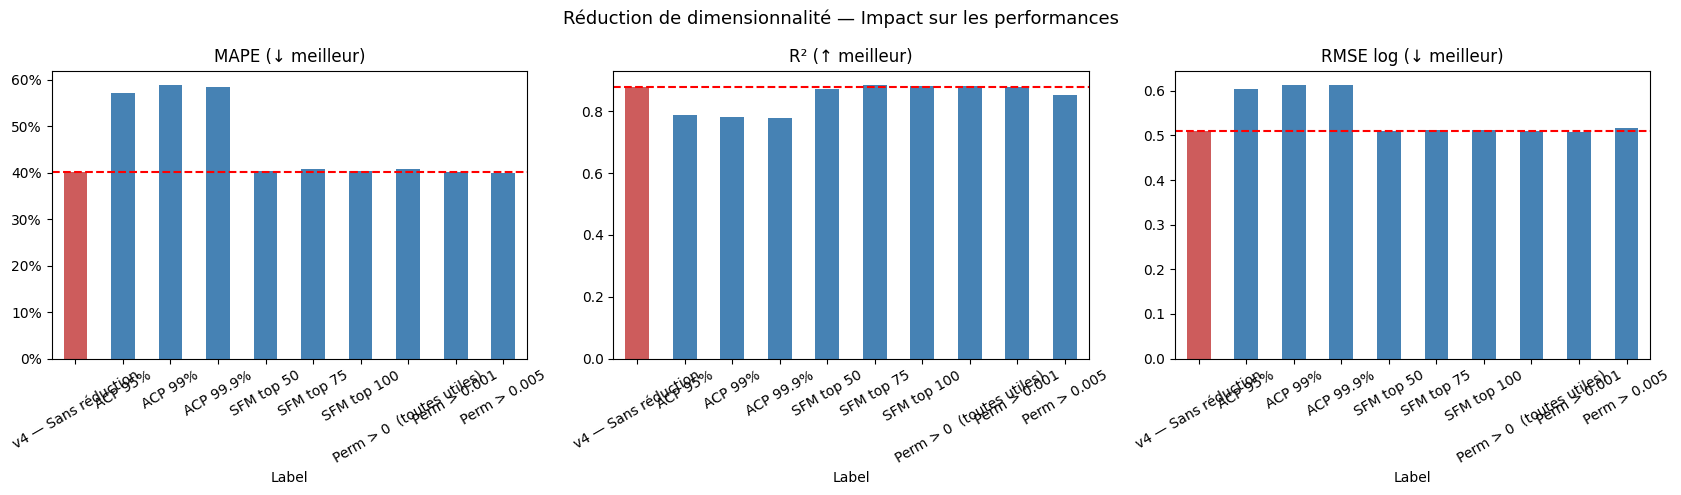

In [ ]:
df_comp = pd.DataFrame(resultats_comparaison).set_index("Label")
df_comp["MAE"]  = df_comp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["RMSE"] = df_comp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["MAPE"] = df_comp["MAPE"].apply(lambda x: f"{x:.2%}")
df_comp["R²"]   = df_comp["R²"].apply(lambda x: f"{x:.4f}")
df_comp["RMSE_log"] = df_comp["RMSE_log"].apply(lambda x: f"{x:.4f}")

print("=== COMPARAISON FINALE (Test) ===")
print(df_comp.to_string())

# Visualisation
df_viz = pd.DataFrame(resultats_comparaison)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ["steelblue" if "Sans" not in l else "indianred" for l in df_viz["Label"]]

df_viz.set_index("Label")["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(res_base["MAPE"], color="red", lw=1.5, linestyle="--", label="baseline")

df_viz.set_index("Label")["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(res_base["R²"], color="red", lw=1.5, linestyle="--")

df_viz.set_index("Label")["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].axhline(res_base["RMSE_log"], color="red", lw=1.5, linestyle="--")

plt.suptitle("Réduction de dimensionnalité — Impact sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

# Normalisation / Standardisation de la variable cible

**Objectif :** tester différentes transformations de `market_value_in_eur` et comparer leurs effets sur les métriques et la lisibilité des résultats.

**Contexte :** la valeur marchande est très asymétrique (skewness > 5). Dans le modèle initial, on utilise `log1p` comme transformation. Ici on teste :

| Transformation | Formule | Espace de prédiction | Interprétation |
|---|---|---|---|
| **Brute** | `y` | Euros | MAE directement en € |
| **log1p** *(baseline)* | `log(1+y)` | Log-euros | Minimise erreurs relatives |
| **log10** | `log10(y)` | Log10-euros | Lisible (M€ → ~7) |
| **sqrt** | `sqrt(y)` | Racine-euros | Compromis |
| **Box-Cox / Yeo-Johnson** | transformation optimale | Variable | Approche statistique |
| **MinMax [0,1]** | `(y-min)/(max-min)` | [0,1] | Métriques normalisées |
| **Rang centile** | `rank/n` | [0,1] | Robuste aux outliers |

Pour chaque transformation, on entraîne le même modèle (XGBoost seul pour la rapidité), on retransforme les prédictions en euros, et on compare les métriques finales **dans le même espace (euros)** pour une comparaison équitable.

## Imports & configuration

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, QuantileTransformer
from scipy import stats
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75

## Chargement & feature engineering

In [82]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

for df in [df_train, df_val, df_test]:
    df.dropna(subset=[colonne_cible], inplace=True)

# log_prev_value anti-leakage
df_history = pd.concat([df_train, df_val, df_test], axis=0).sort_values(["player","season_year"])
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1))
df_train = df_history[df_history["season_year"].isin([2020,2021,2022])].copy()
df_val   = df_history[df_history["season_year"].isin([2023])].copy()
df_test  = df_history[df_history["season_year"].isin([2024])].copy()

# Imputation log_prev_value
def impute_log_prev(df_train, df_target):
    df_target = df_target.copy()
    mask_nan = df_target["log_prev_value"].isna()
    if mask_nan.sum() == 0: return df_target
    medians_prev = df_train.groupby("pos_GK")["log_prev_value"].median()
    df_target.loc[mask_nan,"log_prev_value"] = df_target.loc[mask_nan,"pos_GK"].map(medians_prev)
    df_target["log_prev_value"].fillna(df_train["log_prev_value"].median(), inplace=True)
    return df_target
df_train = impute_log_prev(df_train, df_train)
df_val   = impute_log_prev(df_train, df_val)
df_test  = impute_log_prev(df_train, df_test)

# Imputation xG
league_cols = [c for c in df_train.columns if c.startswith("league_")]
def extraire_ligue(df):
    df = df.copy()
    df["_ligue"] = "Other"
    for col in league_cols:
        df.loc[df[col]==1,"_ligue"] = col.replace("league_","")
    return df
for col in ["xg","xa","xg_buildup"]:
    if col not in df_train.columns: continue
    medians = df_train.pipe(extraire_ligue).groupby(["pos_GK","_ligue"])[col].median()
    def impute(df,col,medians):
        df = df.pipe(extraire_ligue)
        df[col] = df.apply(lambda r: medians.get((r["pos_GK"],r["_ligue"]),
                            df_train[col].median()) if pd.isna(r[col]) else r[col], axis=1)
        return df
    df_train = impute(df_train,col,medians)
    df_val   = impute(df_val,col,medians)
    df_test  = impute(df_test,col,medians)

# Features âge & ratios
def ajouter_features(df):
    df = df.copy()
    if "age" in df.columns:
        df["peak_distance"] = (df["age"]-27).abs()
        df["age_sq"]        = df["age"]**2
        df["is_prime"]      = ((df["age"]>=24)&(df["age"]<=28)).astype(int)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"]/(df["Playing Time_90s"]+0.01)
    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"]  = df["Performance_Ast"]/(df["Playing Time_90s"]+0.01)
    return df
df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

# Suppression des _nor d'abord, PUIS construction de cols_a_supprimer
# sur ce qui reste réellement dans le dataframe
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]
for d in [df_train, df_val, df_test]:
    d.drop(columns=colonnes_nor + ["_ligue"], errors="ignore", inplace=True)

cols_a_supprimer = [c for c in [colonne_cible, colonne_joueur, colonne_team,
                                  colonne_nation, "position"]
                    if c in df_train.columns]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]
X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]
X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

sample_weights = 1/np.log1p(y_train)
sample_weights = sample_weights/sample_weights.mean()

print(f"X_train : {X_train.shape} | n joueurs test : {len(y_test)}")

X_train : (7401, 147) | n joueurs test : 2286


## Analyse de la distribution de la cible

Avant de choisir une transformation, on analyse la distribution de `market_value_in_eur`.

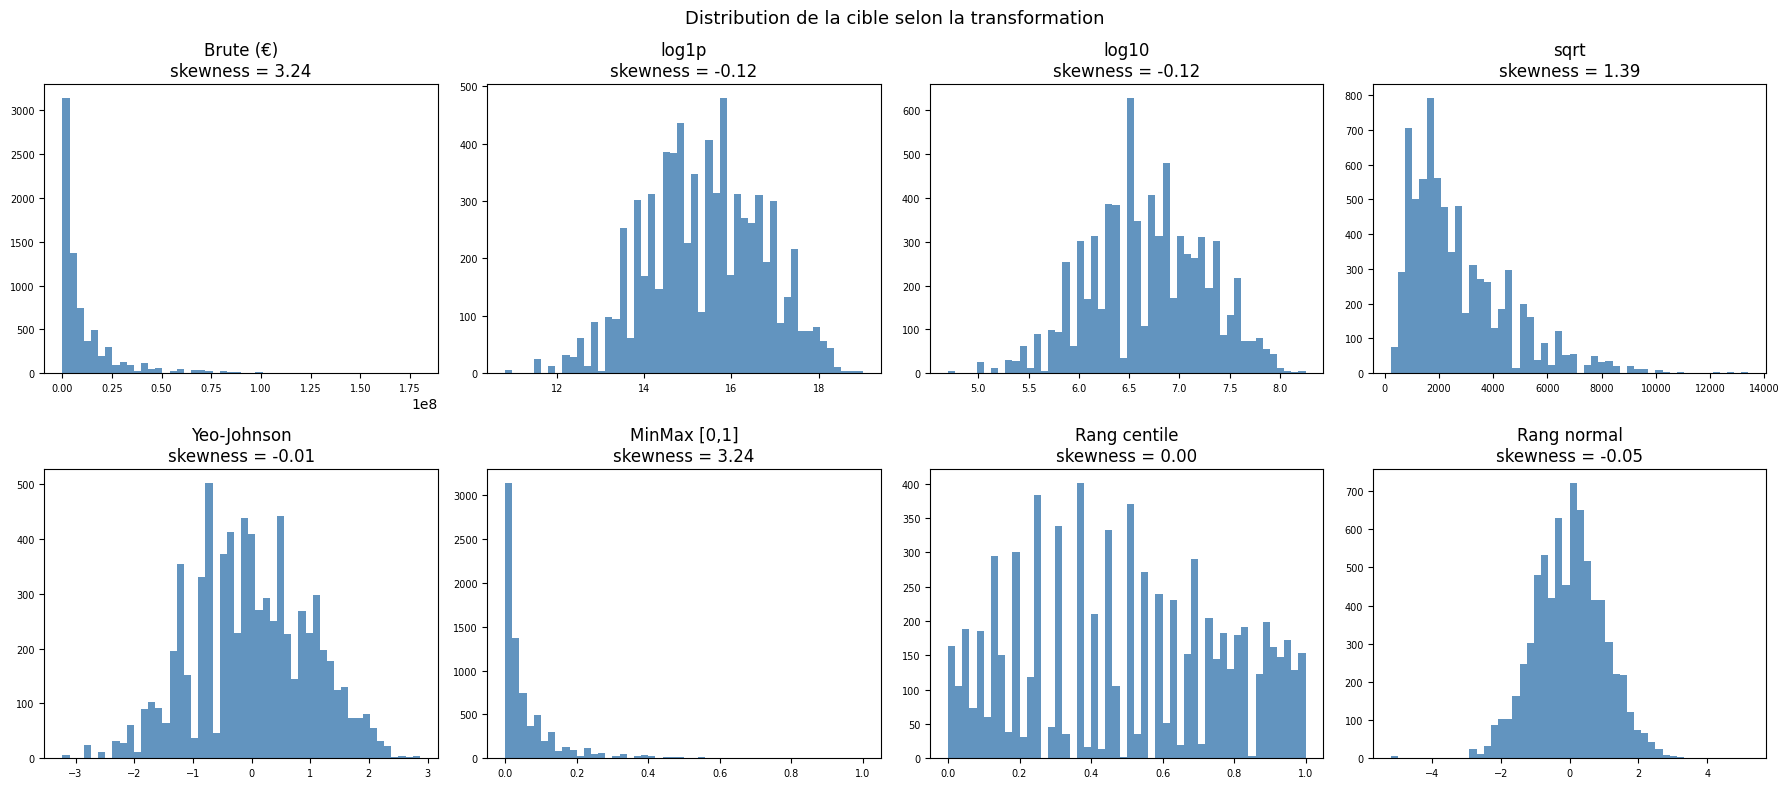

Statistiques de la cible brute :
count    7.401000e+03
mean     1.084837e+07
std      1.553925e+07
min      5.000000e+04
25%      2.000000e+06
50%      5.000000e+06
75%      1.400000e+07
max      1.800000e+08
Name: market_value_in_eur, dtype: float64
Skewness brute : 3.24
Skewness log1p : -0.12


In [83]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

transformations_viz = {
    "Brute (€)":           y_train,
    "log1p":               np.log1p(y_train),
    "log10":               np.log10(y_train),
    "sqrt":                np.sqrt(y_train),
    "Yeo-Johnson":         pd.Series(PowerTransformer(method="yeo-johnson")
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "MinMax [0,1]":        pd.Series(MinMaxScaler()
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang centile":        pd.Series(QuantileTransformer(output_distribution="uniform",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang normal":         pd.Series(QuantileTransformer(output_distribution="normal",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
}

for ax, (label, y_t) in zip(axes.flatten(), transformations_viz.items()):
    ax.hist(y_t, bins=50, color="steelblue", edgecolor="none", alpha=0.85)
    skew = float(pd.Series(y_t).skew())
    ax.set_title(f"{label}\nskewness = {skew:.2f}")
    ax.tick_params(labelsize=7)

plt.suptitle("Distribution de la cible selon la transformation", fontsize=13)
plt.tight_layout()
plt.show()

print("Statistiques de la cible brute :")
print(y_train.describe())
print(f"Skewness brute : {y_train.skew():.2f}")
print(f"Skewness log1p : {np.log1p(y_train).skew():.2f}")

## Définition des transformations & fonctions utilitaires

Pour chaque transformation, on définit :
- `transform(y)` : transforme les euros en espace de modélisation
- `inverse(y_pred)` : retransforme les prédictions en euros

Les transformateurs dépendants des données (Yeo-Johnson, MinMax, QuantileTransformer) sont **fittés uniquement sur le train** pour éviter toute fuite.

In [ ]:
# Fitter les transformateurs data-dependent sur le TRAIN uniquement
yj_transformer = PowerTransformer(method="yeo-johnson")
yj_transformer.fit(y_train.values.reshape(-1,1))

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(y_train.values.reshape(-1,1))

quantile_unif = QuantileTransformer(output_distribution="uniform", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_unif.fit(y_train.values.reshape(-1,1))

quantile_norm = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_norm.fit(y_train.values.reshape(-1,1))

transformations = {
    "Brute": {
        "transform": lambda y: y,
        "inverse":   lambda y: np.clip(y, 0, None),
        "description": "Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les erreurs absolues en €, donc surpondère les stars.",
    },
    "log1p (baseline)": {
        "transform": lambda y: np.log1p(y),
        "inverse":   lambda y: np.expm1(y),
        "description": "log(1+y) — transformation de référence. Compresse l'échelle, donne le même poids à chaque ordre de grandeur.",
    },
    "log10": {
        "transform": lambda y: np.log10(np.clip(y, 1, None)),
        "inverse":   lambda y: np.power(10, y),
        "description": "log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10M€, 7.7 = 50M€.",
    },
    "sqrt": {
        "transform": lambda y: np.sqrt(y),
        "inverse":   lambda y: np.square(np.clip(y, 0, None)),
        "description": "Racine carrée — compression plus douce que le log. Bon compromis si la distribution est modérément asymétrique.",
    },
    "Yeo-Johnson": {
        "transform": lambda y: yj_transformer.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(yj_transformer.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automatiquement la transformation optimale par maximum de vraisemblance.",
    },
    "MinMax [0,1]": {
        "transform": lambda y: minmax_scaler.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(minmax_scaler.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). Métriques en [0,1] très lisibles mais peu robustes.",
    },
    "Rang centile [0,1]": {
        "transform": lambda y: quantile_unif.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_unif.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en rangs uniformes [0,1]. Robuste aux outliers, distribution parfaitement uniforme. Problème : perd la notion d'amplitude entre valeurs.",
    },
    "Rang normal": {
        "transform": lambda y: quantile_norm.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_norm.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en distribution normale centrée réduite. Bien adapté aux modèles supposant la normalité des résidus.",
    },
}

print(f"{len(transformations)} transformations définies.")

8 transformations définies.


## Entraînement et évaluation pour chaque transformation

In [ ]:
def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_true),
                                           np.log1p(np.clip(y_pred,0,None))))
    return {"Transformation": label, "MAE": mae, "RMSE": rmse,
            "MAPE": mape, "R²": r2, "RMSE_log": rmse_log}

# Modèle XGBoost fixe (hyperparamètres du modèle initial) — on ne retune pas pour que la
# comparaison soit équitable (on ne veut pas confondre l'effet de la
# transformation avec l'effet du tuning)
def make_xgb():
    return XGBRegressor(
        n_estimators=1500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.01, reg_lambda=1.5,
        tree_method="hist", enable_categorical=True,
        objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

resultats = []
predictions_test = {}

for label, transfo in transformations.items():
    print(f"\n--- {label} ---")
    print(f"  {transfo['description'][:80]}...")

    try:
        y_tr_t  = transfo["transform"](y_train)
        y_val_t = transfo["transform"](y_val)
        y_te_t  = transfo["transform"](y_test)  # uniquement pour info

        # Poids adaptés : toujours sur-pondérer les petites valeurs EN EUROS
        # (indépendamment de la transformation utilisée pour la cible)
        sw = sample_weights.values

        xgb = make_xgb()
        xgb.fit(X_train, y_tr_t, sample_weight=sw)

        # Prédictions sur le test → retransformer en euros
        preds_t = xgb.predict(X_test)
        preds_eur = transfo["inverse"](preds_t if isinstance(preds_t, np.ndarray) else np.array(preds_t))

        res = evaluer_complet(label, y_test.values, preds_eur)
        resultats.append(res)
        predictions_test[label] = preds_eur

        print(f"  → MAPE: {res['MAPE']:.2%} | R²: {res['R²']:.4f} | "
              f"MAE: {res['MAE']:>10,.0f}€ | RMSE_log: {res['RMSE_log']:.4f}")

    except Exception as e:
        print(f"  ⚠️ Erreur : {e}")


--- Brute ---
  Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les err...
  → MAPE: 69.41% | R²: 0.8824 | MAE:  3,508,385€ | RMSE_log: 1.4584

--- log1p (v4 baseline) ---
  log(1+y) — transformation de référence v4. Compresse l'échelle, donne le même po...
  → MAPE: 41.46% | R²: 0.8724 | MAE:  3,374,610€ | RMSE_log: 0.5187

--- log10 ---
  log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10...
  → MAPE: 41.32% | R²: 0.8750 | MAE:  3,336,373€ | RMSE_log: 0.5161

--- sqrt ---
  Racine carrée — compression plus douce que le log. Bon compromis si la distribut...
  → MAPE: 48.68% | R²: 0.8868 | MAE:  3,248,676€ | RMSE_log: 0.5349

--- Yeo-Johnson ---
  Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automa...
  → MAPE: 42.03% | R²: 0.8755 | MAE:  3,343,186€ | RMSE_log: 0.5140

--- MinMax [0,1] ---
  Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). ...
  → MAPE: 66.74% | R²: 0.883

## Tableau comparatif

=== CLASSEMENT PAR MAPE (↓ meilleur) ===
                                MAE            RMSE    MAPE      R² RMSE_log
Transformation                                                              
log10                   3,336,373 €     6,611,748 €  41.32%  0.8750   0.5161
log1p (v4 baseline)     3,374,610 €     6,681,317 €  41.46%  0.8724   0.5187
Rang normal             3,240,686 €     6,339,256 €  41.58%  0.8851   0.5202
Yeo-Johnson             3,343,186 €     6,599,398 €  42.03%  0.8755   0.5140
sqrt                    3,248,676 €     6,292,365 €  48.68%  0.8868   0.5349
Rang centile [0,1]      5,038,089 €    15,012,912 €  50.16%  0.3557   0.5616
MinMax [0,1]            3,477,567 €     6,378,364 €  66.74%  0.8837   1.3900
Brute                   3,508,385 €     6,414,253 €  69.41%  0.8824   1.4584


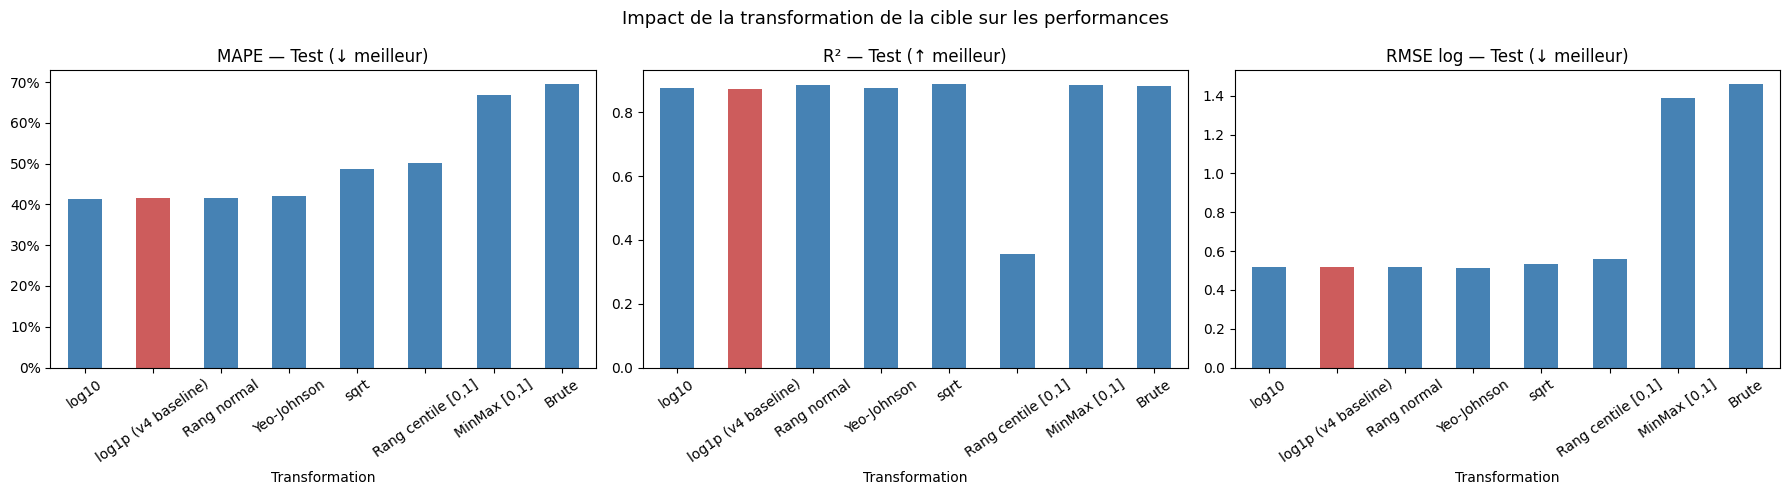

In [86]:
df_res = pd.DataFrame(resultats).set_index("Transformation")
df_res_sorted = df_res.sort_values("MAPE")

print("=== CLASSEMENT PAR MAPE (↓ meilleur) ===")
df_display = df_res_sorted.copy()
df_display["MAE"]      = df_display["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["RMSE"]     = df_display["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["MAPE"]     = df_display["MAPE"].apply(lambda x: f"{x:.2%}")
df_display["R²"]       = df_display["R²"].apply(lambda x: f"{x:.4f}")
df_display["RMSE_log"] = df_display["RMSE_log"].apply(lambda x: f"{x:.4f}")
print(df_display.to_string())

# Barplot des métriques clés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["indianred" if "baseline" in l else "steelblue" for l in df_res_sorted.index]

df_res_sorted["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE — Test (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=35)

df_res_sorted["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² — Test (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=35)

df_res_sorted["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log — Test (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle("Impact de la transformation de la cible sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

## Analyse par tranche de valeur

=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===
Transformation                     <5M€   5-20M€  20-50M€    >50M€
-----------------------------------------------------------------
Brute                           116.9%    31.8%    20.7%    19.4%
log1p (v4 baseline)              57.3%    30.6%    21.8%    22.2%
log10                            57.4%    30.3%    21.7%    21.6%
sqrt                             74.2%    29.6%    20.4%    19.5%
Yeo-Johnson                      59.1%    29.8%    22.0%    22.3%
MinMax [0,1]                    111.8%    31.0%    20.4%    19.6%
Rang centile [0,1]               69.3%    29.6%    35.8%    60.1%
Rang normal                      57.9%    31.0%    20.5%    19.8%


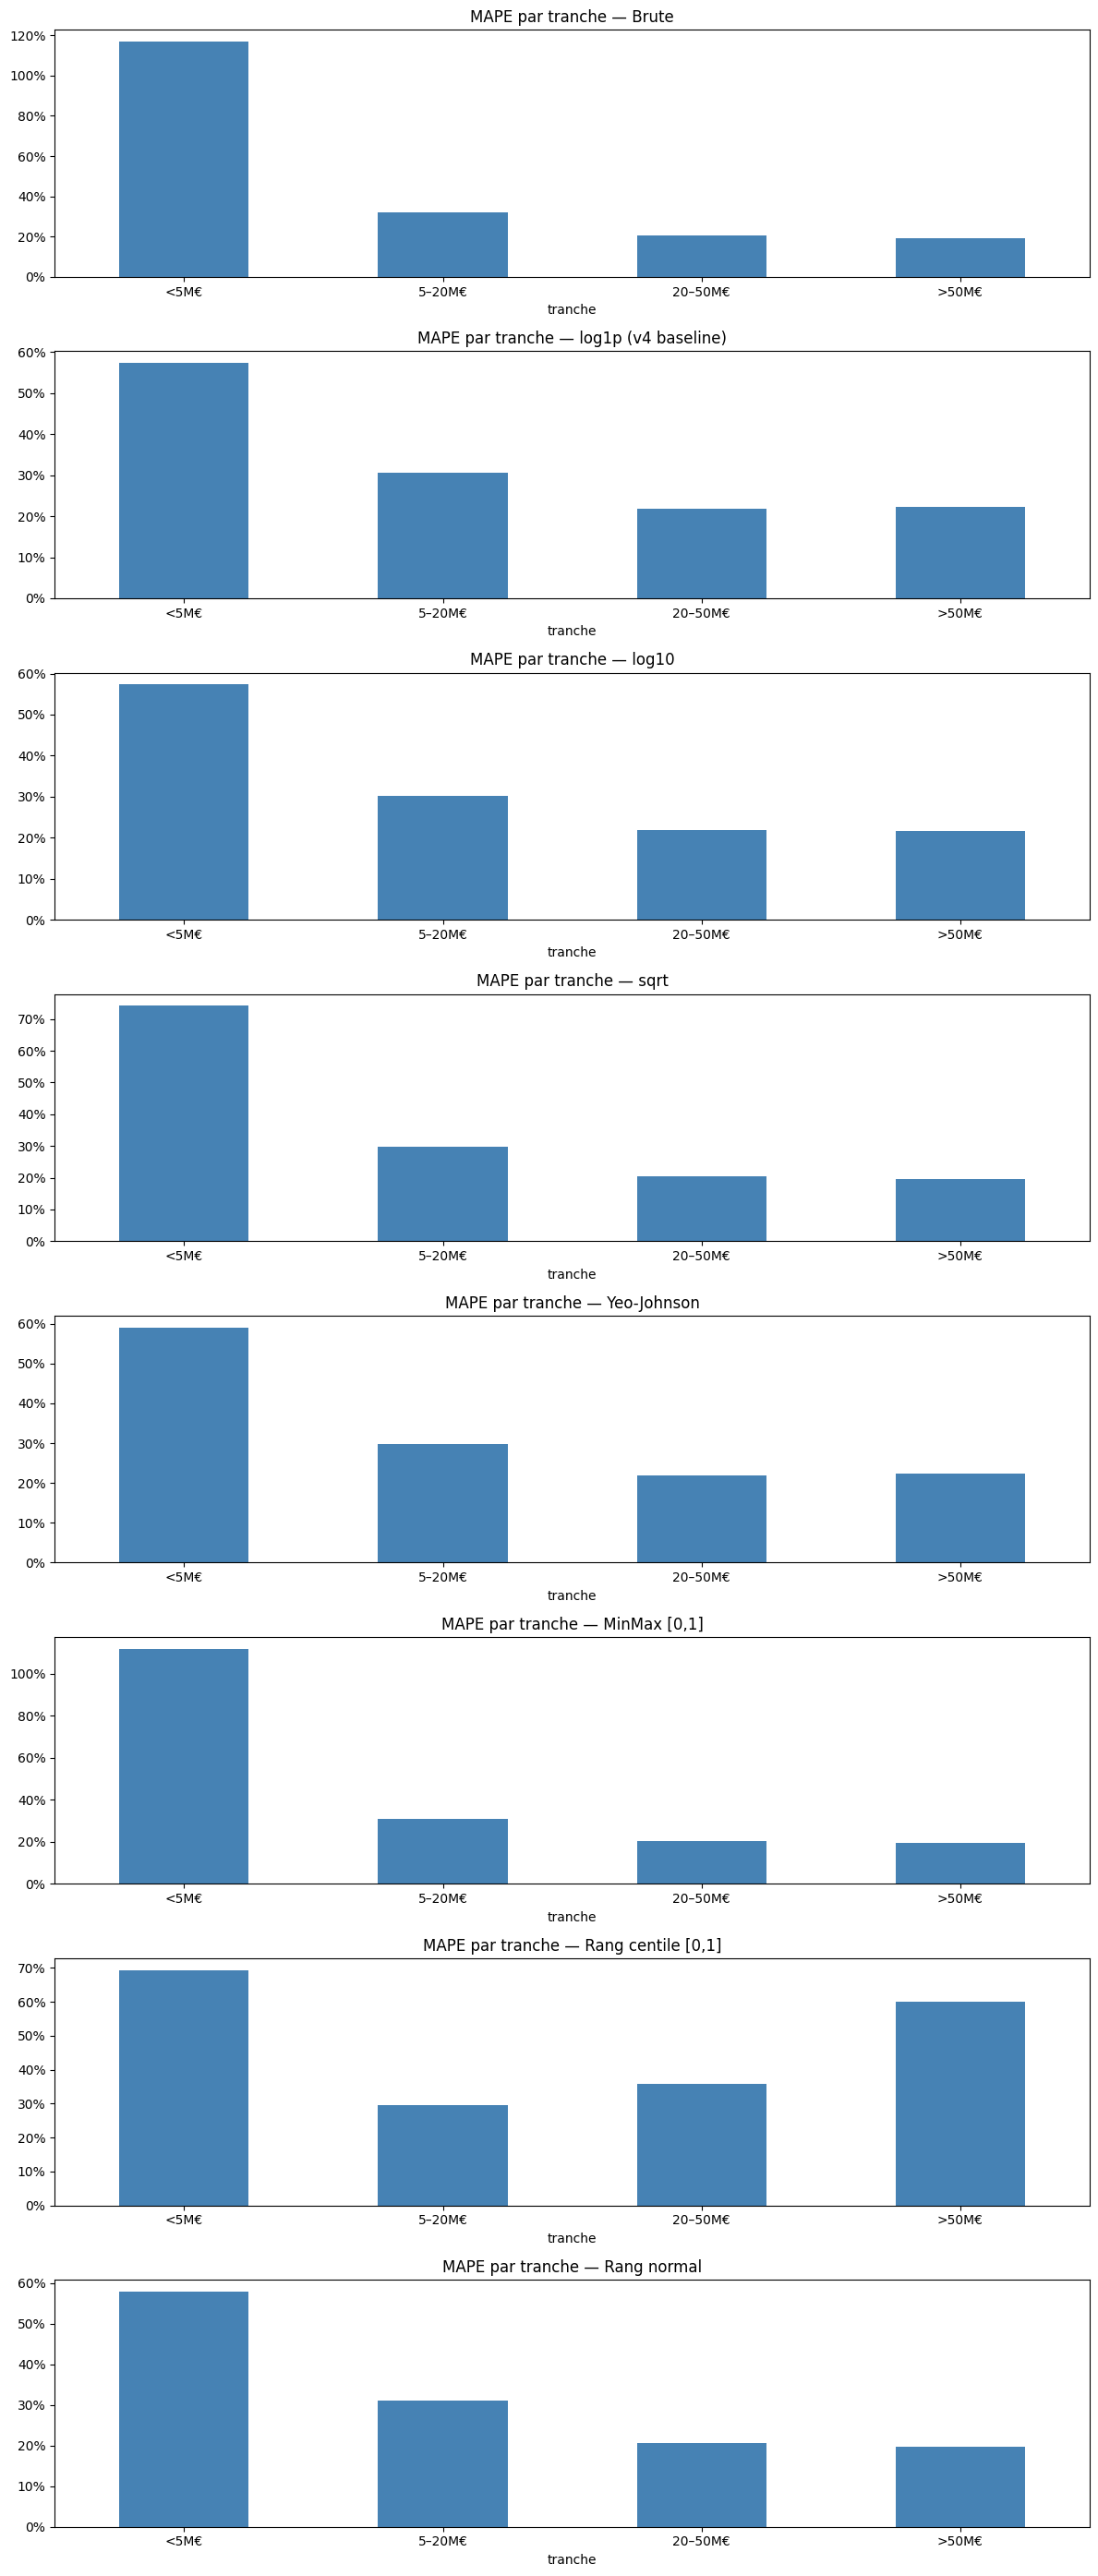

In [87]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€","5–20M€","20–50M€",">50M€"]

fig, axes = plt.subplots(len(predictions_test), 1, figsize=(12, 3.5*len(predictions_test)))
if len(predictions_test) == 1: axes = [axes]

print("=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===")
print(f"{'Transformation':30s} {'<5M€':>8} {'5-20M€':>8} {'20-50M€':>8} {'>50M€':>8}")
print("-"*65)

for ax, (label, preds) in zip(axes, predictions_test.items()):
    df_err = pd.DataFrame({"y": y_test.values, "pred": preds})
    df_err["err_pct"] = (df_err["y"]-df_err["pred"]).abs()/df_err["y"]
    df_err["tranche"] = pd.cut(df_err["y"], bins=tranches, labels=labels_tranches)

    mapes = df_err.groupby("tranche", observed=True)["err_pct"].mean()
    print(f"{label:30s} {mapes.get('<5M€',np.nan):>7.1%} {mapes.get('5–20M€',np.nan):>8.1%} "
          f"{mapes.get('20–50M€',np.nan):>8.1%} {mapes.get('>50M€',np.nan):>8.1%}")

    mapes.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"MAPE par tranche — {label}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Tuning Optuna avec la meilleure transformation

In [88]:
# On identifie la meilleure transformation selon le MAPE
meilleure_transfo = df_res["MAPE"].idxmin()
print(f"Meilleure transformation selon MAPE : {meilleure_transfo}")
print(f"MAPE : {df_res.loc[meilleure_transfo, 'MAPE']:.2%}")
print(f"R²   : {df_res.loc[meilleure_transfo, 'R²']:.4f}")

# Si la meilleure n'est pas log1p, on tune XGB+LGBM+CAT + stacking OOF
# avec la meilleure transformation pour voir le plein potentiel
transfo_best = transformations[meilleure_transfo]
y_tr_best  = pd.Series(transfo_best["transform"](y_train), index=y_train.index)
y_val_best = pd.Series(transfo_best["transform"](y_val),   index=y_val.index)
y_te_best  = pd.Series(transfo_best["transform"](y_test),  index=y_test.index)

print(f"\nDistribution de la cible transformée ({meilleure_transfo}) :")
print(y_tr_best.describe())
print(f"Skewness : {y_tr_best.skew():.3f}")

Meilleure transformation selon MAPE : log10
MAPE : 41.32%
R²   : 0.8750

Distribution de la cible transformée (log10) :
count    7401.000000
mean        6.690504
std         0.576354
min         4.698970
25%         6.301030
50%         6.698970
75%         7.146128
max         8.255273
Name: market_value_in_eur, dtype: float64
Skewness : -0.117


In [89]:
def objective_xgb_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":"hist","enable_categorical":True,"objective":"reg:squarederror",
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbosity":0,
    }
    m = XGBRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights)
    preds_t   = m.predict(X_val)
    preds_eur = transfo_best["inverse"](preds_t)
    # Optimiser RMSE log (≈ MAPE) dans l'espace euros pour cohérence
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning XGBoost avec transformation '{meilleure_transfo}' ---")
study_xgb_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_best.optimize(objective_xgb_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_xgb_best.best_value:.4f}")
print(f"Params : {study_xgb_best.best_params}")

--- Tuning XGBoost avec transformation 'log10' ---


Best trial: 69. Best value: 0.50821: 100%|██████████| 75/75 [25:45<00:00, 20.61s/it] 

Meilleur RMSE log : 0.5082
Params : {'n_estimators': 2000, 'max_depth': 9, 'learning_rate': 0.0057455338454447495, 'subsample': 0.6618243936904344, 'colsample_bytree': 0.9276781729186957, 'min_child_weight': 9.36818474536441, 'reg_alpha': 0.00047782872304221667, 'reg_lambda': 1.9102735540447542}


In [90]:
def objective_lgbm_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbose":-1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning LightGBM ---")
study_lgbm_best = optuna.create_study(direction="minimize",
                                       sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_best.optimize(objective_lgbm_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_lgbm_best.best_value:.4f}")

def objective_cat_best(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":"Bernoulli","random_state":RANDOM_STATE,
        "early_stopping_rounds":50,"verbose":0,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
          sample_weight=sample_weights, verbose=False)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning CatBoost ---")
study_cat_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_best.optimize(objective_cat_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_cat_best.best_value:.4f}")

--- Tuning LightGBM ---


Best trial: 58. Best value: 0.509215: 100%|██████████| 75/75 [13:41<00:00, 10.96s/it]


Meilleur RMSE log : 0.5092
--- Tuning CatBoost ---


Best trial: 71. Best value: 0.519277: 100%|██████████| 75/75 [23:42<00:00, 18.97s/it]

Meilleur RMSE log : 0.5193


In [91]:
# Stacking OOF avec la meilleure transformation
xgb_f = XGBRegressor(**study_xgb_best.best_params, tree_method="hist",
                      enable_categorical=True, objective="reg:squarederror",
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgbm_f = LGBMRegressor(**study_lgbm_best.best_params,
                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_f  = CatBoostRegressor(**study_cat_best.best_params, bootstrap_type="Bernoulli",
                             random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0)

modeles_f = {"XGBoost": xgb_f, "LightGBM": lgbm_f, "CatBoost": cat_f}
sw = sample_weights.values

# OOF
print("Génération OOF...")
oof = {}
for nom, m in modeles_f.items():
    oof[nom] = cross_val_predict(m, X_train, y_tr_best, cv=5, n_jobs=-1)
    preds_eur_oof = transfo_best["inverse"](oof[nom])
    mape_oof = mean_absolute_percentage_error(y_train, preds_eur_oof)
    print(f"  {nom}: OOF MAPE = {mape_oof:.2%}")

X_meta_tr = pd.DataFrame(oof)

# Ré-entraînement
for nom, m in modeles_f.items():
    if isinstance(m, CatBoostRegressor):
        m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
              sample_weight=sw, verbose=False)
    else:
        m.fit(X_train, y_tr_best, sample_weight=sw)

X_meta_val = pd.DataFrame({n: m.predict(X_val)  for n,m in modeles_f.items()})
X_meta_te  = pd.DataFrame({n: m.predict(X_test) for n,m in modeles_f.items()})

meta = LinearRegression(positive=True)
meta.fit(X_meta_tr, y_tr_best)
print(f"Poids méta : { {n:round(w,3) for n,w in zip(modeles_f.keys(),meta.coef_)} }")

pred_test_tuned_eur = transfo_best["inverse"](meta.predict(X_meta_te))

res_tuned = evaluer_complet(f"Tuné + Stack ({meilleure_transfo})", y_test.values, pred_test_tuned_eur)
print(f"\n=== RÉSULTAT FINAL (tuné, stacking OOF) ===")
print(f"  MAPE     : {res_tuned['MAPE']:.2%}")
print(f"  R²       : {res_tuned['R²']:.4f}")
print(f"  MAE      : {res_tuned['MAE']:>12,.0f} €")
print(f"  RMSE_log : {res_tuned['RMSE_log']:.4f}")
resultats.append(res_tuned)

Génération OOF...
  XGBoost: OOF MAPE = 42.22%
  LightGBM: OOF MAPE = 42.44%
  CatBoost: OOF MAPE = 42.53%
Poids méta : {'XGBoost': np.float64(0.279), 'LightGBM': np.float64(0.186), 'CatBoost': np.float64(0.556)}

=== RÉSULTAT FINAL (tuné, stacking OOF) ===
  MAPE     : 38.90%
  R²       : 0.8871
  MAE      :    3,226,705 €
  RMSE_log : 0.5035


## Résultat final — comparaison avec le modèle initial

In [ ]:
# Référence (Stacking OOF, log1p, tuné)
v4_ref = {"Transformation": "log1p — modèle référence (tuné)",
           "MAPE": 0.3857, "R²": 0.880, "MAE": 3_340_118,
           "RMSE": None, "RMSE_log": 0.552}

df_final = pd.DataFrame(resultats + [v4_ref]).set_index("Transformation")
df_final = df_final.sort_values("MAPE")

print("=== CLASSEMENT FINAL ===")
for col in ["MAPE","R²","RMSE_log"]:
    df_final[col] = df_final[col].apply(lambda x:
        f"{x:.2%}" if col=="MAPE" else f"{x:.4f}" if x is not None else "—")
print(df_final[["MAPE","R²","RMSE_log"]].to_string())

=== CLASSEMENT FINAL ===
                               MAPE      R² RMSE_log
Transformation                                      
log1p — v4 référence (tuné)  38.57%  0.8800   0.5520
Tuné + Stack (log10)         38.90%  0.8871   0.5035
log10                        41.32%  0.8750   0.5161
log1p (v4 baseline)          41.46%  0.8724   0.5187
Rang normal                  41.58%  0.8851   0.5202
Yeo-Johnson                  42.03%  0.8755   0.5140
sqrt                         48.68%  0.8868   0.5349
Rang centile [0,1]           50.16%  0.3557   0.5616
MinMax [0,1]                 66.74%  0.8837   1.3900
Brute                        69.41%  0.8824   1.4584
